# Create the understandability index


This is the main notebook where we create our understandability index.

Steps:

1. Feature Extraction
   - Use spaCy and textdescriptives to extract linguistic features and readability metrics.
   - Calculate the percentage of standard CEFR vocabulary and common words.
2. Data Analysis
   - Examine how features are distributed across different text types.
3. Modeling
   - Use a Gaussian Mixture Model to identify outliers.
   - Create a Ridge Regression model using estimated difficulty levels as the target variable.
   - Choose a set of meaningful features that cover both syntactic and semantic aspects.
4. Index Creation
   - Train Ridge model on chosen features.
   - Scale predicted scores from the model to a scale from -10 to 10.
   - Find sensible limits for CEFR levels:
     - Negative scores (-10 to 0): More complex texts (B2 to C2).
     - Positive scores (0 to 10): Simpler texts (B1 to A1).
5. Finalization
   - Refactor the index into a separate, reusable module that is pip installable.


**Imports**


In [4]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt

plt.style.use("ggplot")

params = {
    "text.color": (0.25, 0.25, 0.25),
    "figure.figsize": [16, 9],
}

plt.rcParams.update(params)

# Get colors from default theme.
DEFAULT_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]

import seaborn as sns

import pandas as pd
from pandarallel import pandarallel
import numpy as np

pd.options.mode.chained_assignment = None
pd.options.display.max_rows = 500
pd.options.display.max_seq_items = 500
pandarallel.initialize(progress_bar=True)

from pickle import dump
from tqdm.notebook import tqdm
import warnings

warnings.simplefilter("ignore", category=UserWarning)

from utils_nlp import (
    extract_text_features,
    punctuate_lines,
)

import spacy

nlp = spacy.load("de_core_news_sm")

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_val_score, train_test_split

INFO: Pandarallel will run on 10 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


**Constants and functions**


In [5]:
INPUT_DIR = "_input/"

# Extract features


In [6]:
df = pd.read_parquet(f"{INPUT_DIR}zix_dataset.parquet")
df = df.sample(frac=1, random_state=42)
df.reset_index(drop=True, inplace=True)
df.head()

,text_type,text
0,Legal,BRKE I Nr. 289/2003 vom 24. Oktober 2003 in BE...
1,C2,Der Park entfaltete sich gestern als ein viels...
2,C1,Die morgendliche Fahrt zur Universität wird du...
3,B1,Bildungspolitik beschäftigt sich mit allen Fra...
4,C2,An einem typisch übervollen Morgen navigiert d...


In [7]:
# Make sure all lines end with punctuation so that sentence lengths can be calculated correctly.
df.text = df.text.apply(punctuate_lines)

We extract features with spaCy and [TextDescriptives](https://github.com/HLasse/TextDescriptives), which is a useful package for extracting a wide variety of text metrics. We experimented with all the features that textdescriptives offers. For simplicity, we show here only a subset of features that we deem interesting for our index.


In [8]:
features = df.text.parallel_apply(extract_text_features)
features = pd.concat(features.values).reset_index(drop=True)
df = pd.concat([df, features], axis=1)

# Explore data


In [9]:
relevant_cols = [
    ## Descriptive stats ------------------------------
    "proportion_unique_tokens",
    "token_length_mean",
    "token_length_std",
    "syllables_per_token_mean",
    "syllables_per_token_std",
    "sentence_length_mean",
    "sentence_length_std",
    ## Additional metrics -----------------------------
    "vocab_a1",
    "vocab_a2",
    "vocab_b1",
    "common_word_score",
    ## Readability ------------------------------------
    "flesch_kincaid_grade",
    # # We leave out Smog since it sometimes returns NaNs for short texts.
    # "smog",
    "gunning_fog",
    "automated_readability_index",
    "coleman_liau_index",
    "lix",
    "rix",
]

order = [
    "A1",
    "A2",
    "B1",
    "B2",
    "C1",
    "C2",
    "Admin News",
    "Legal",
]

From the mean feature values, we can roughly intuit the difficulty of the various text types. No super clear picture emerges yet. The ranking depends very much on the features we look at.


In [10]:
df.groupby("text_type")[relevant_cols].mean().sort_values("rix").T[order].style.format(
    "{:.5f}"
)

text_type,A1,A2,B1,B2,C1,C2,Admin News,Legal
proportion_unique_tokens,0.75483,0.78529,0.78935,0.79557,0.79274,0.78169,0.68224,0.42896
token_length_mean,4.87212,5.28830,5.93760,6.68026,7.29927,7.82117,6.48186,6.36030
token_length_std,2.26027,2.67270,3.28601,3.87674,4.33044,4.67024,4.14817,4.37056
syllables_per_token_mean,1.58350,1.74442,1.97022,2.23235,2.46089,2.67426,2.14697,2.10489
syllables_per_token_std,0.77885,0.92938,1.13564,1.35346,1.52812,1.68790,1.42435,1.41620
sentence_length_mean,5.59313,7.76992,10.43736,12.79889,15.71243,19.33387,16.28704,16.40288
sentence_length_std,1.00138,1.26666,1.77650,2.28986,3.00127,3.79186,6.94562,12.25393
vocab_a1,0.74524,0.68349,0.58998,0.49379,0.43538,0.39878,0.51582,0.45145
vocab_a2,0.81950,0.77199,0.67620,0.56583,0.49225,0.44485,0.56441,0.49569
vocab_b1,0.88394,0.86362,0.79914,0.70492,0.61855,0.54482,0.66532,0.60331


From the plots, we can see some features that seem expressive regarding our assumed difficulty ranking, e.g., token and sentence lengths, the readability metrics, as well as our common word score and the vocabularies.


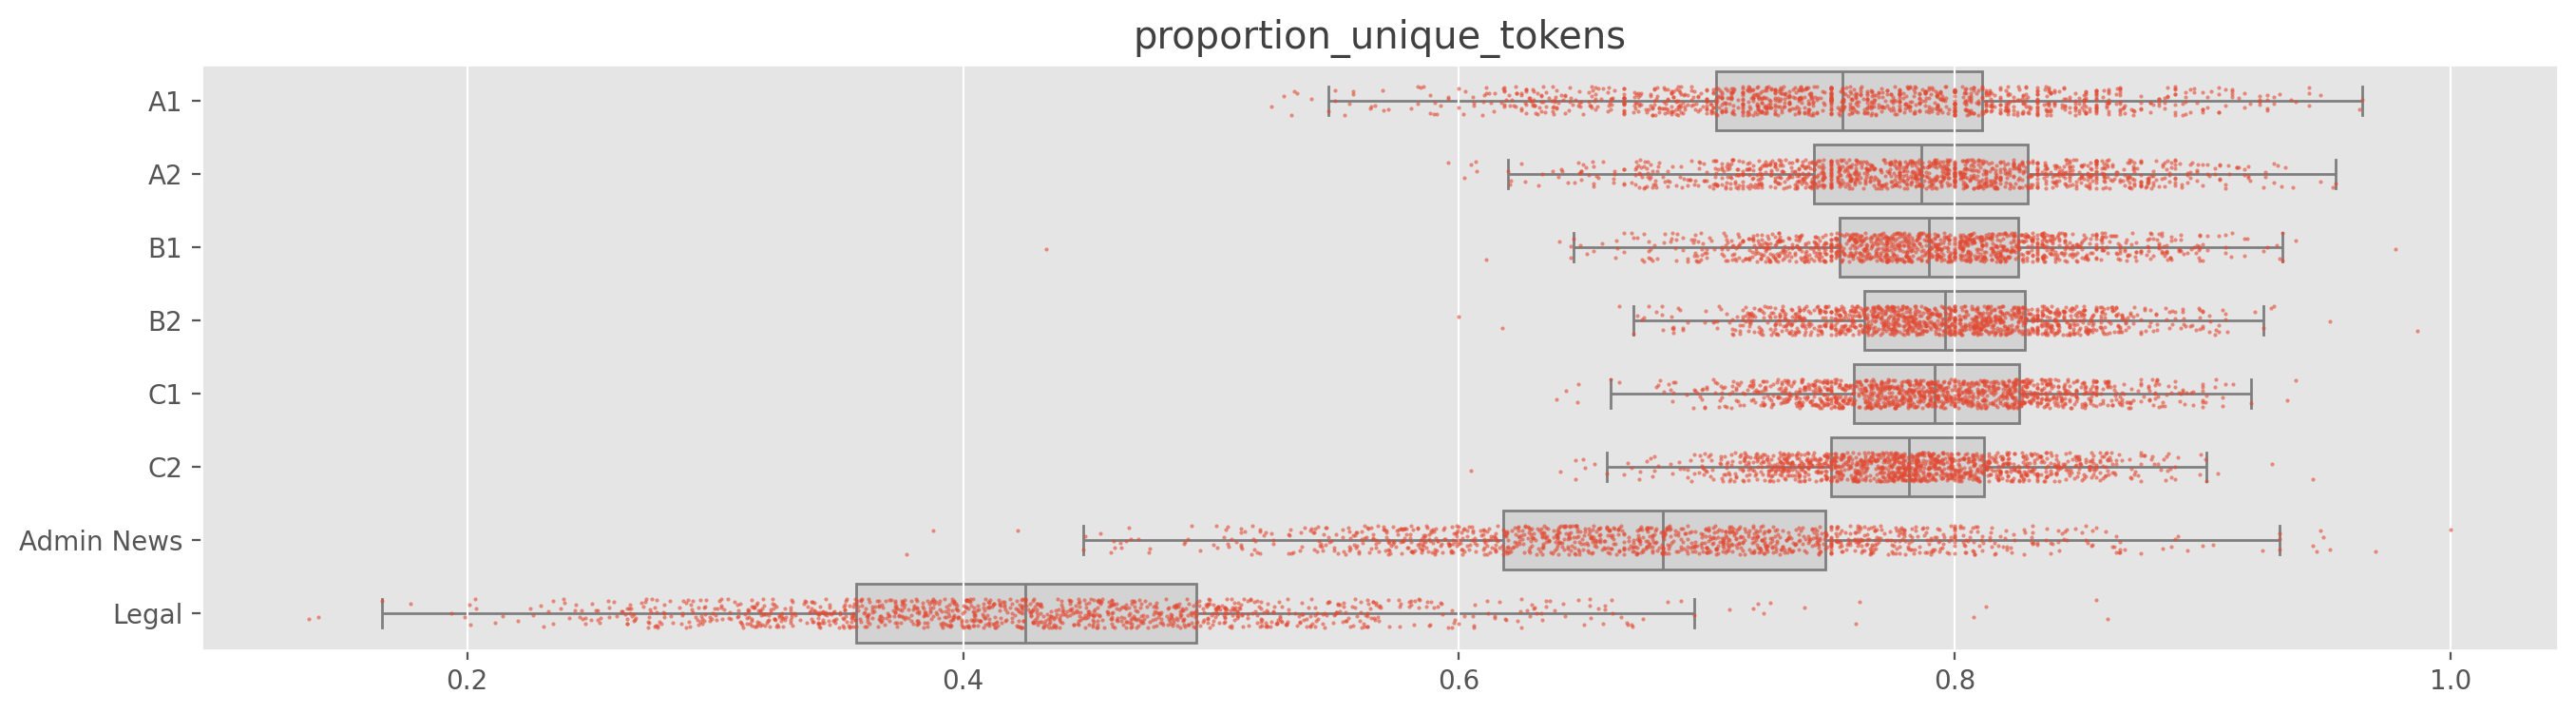

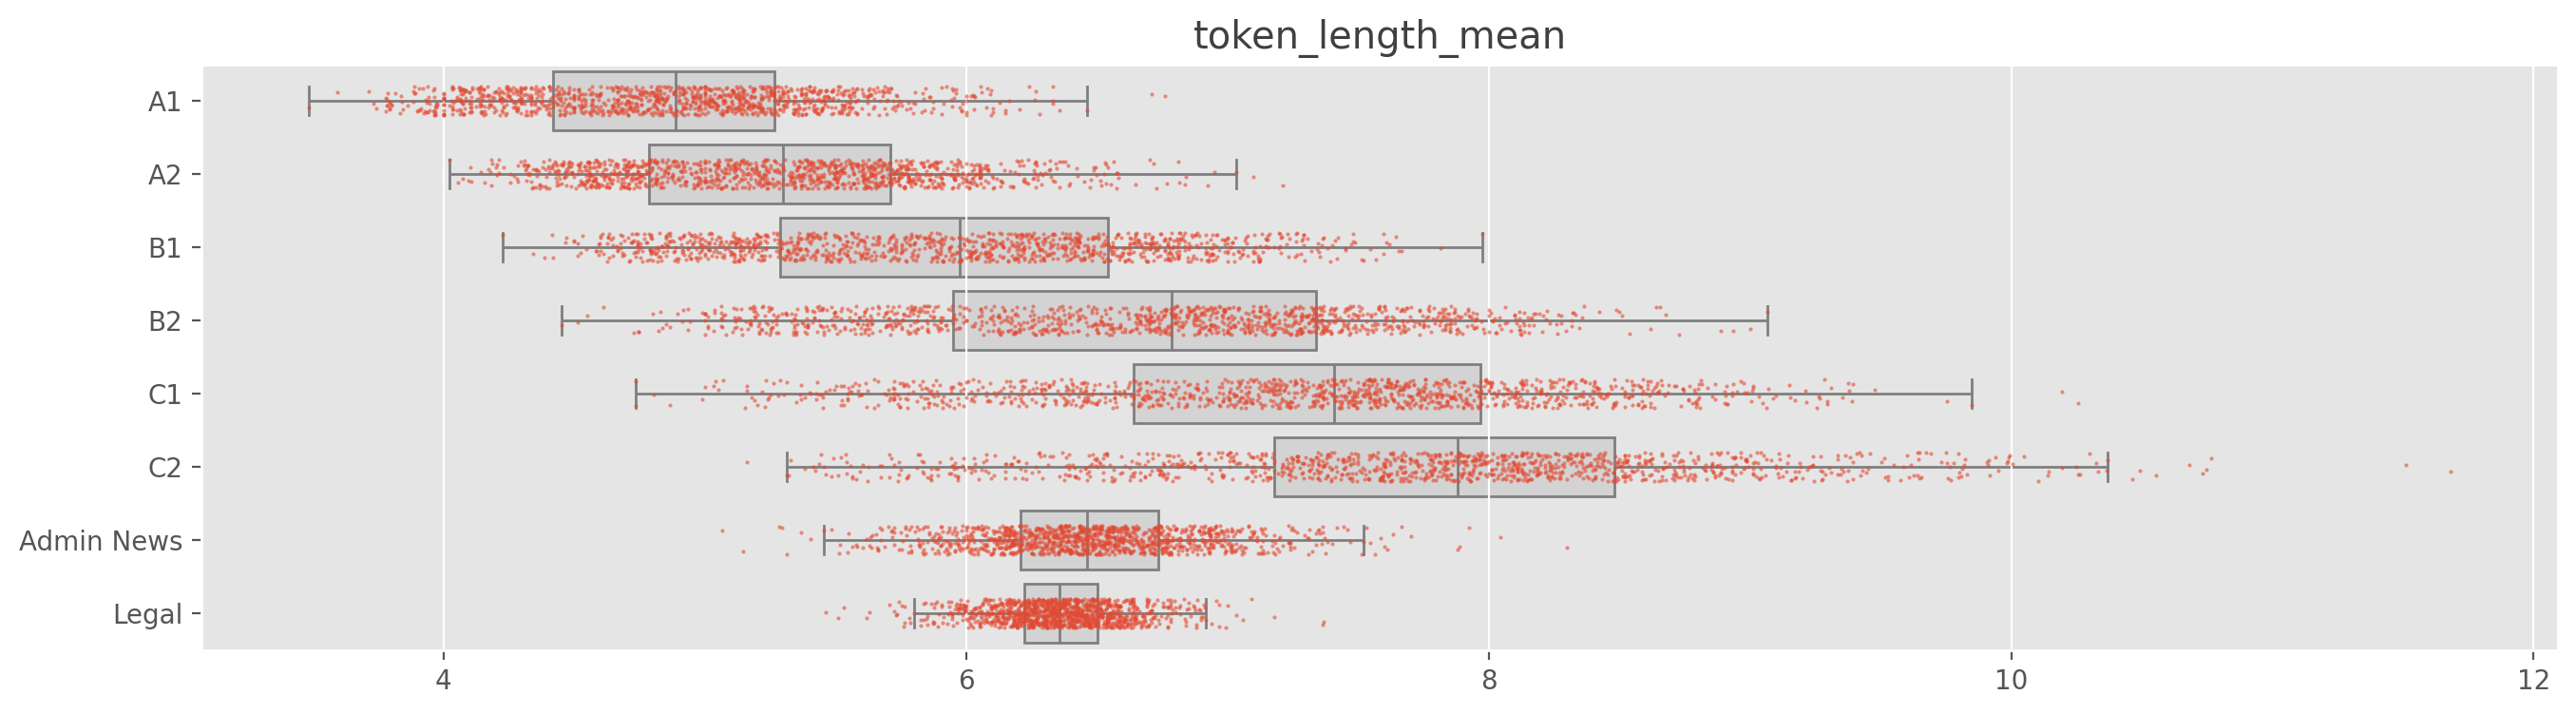

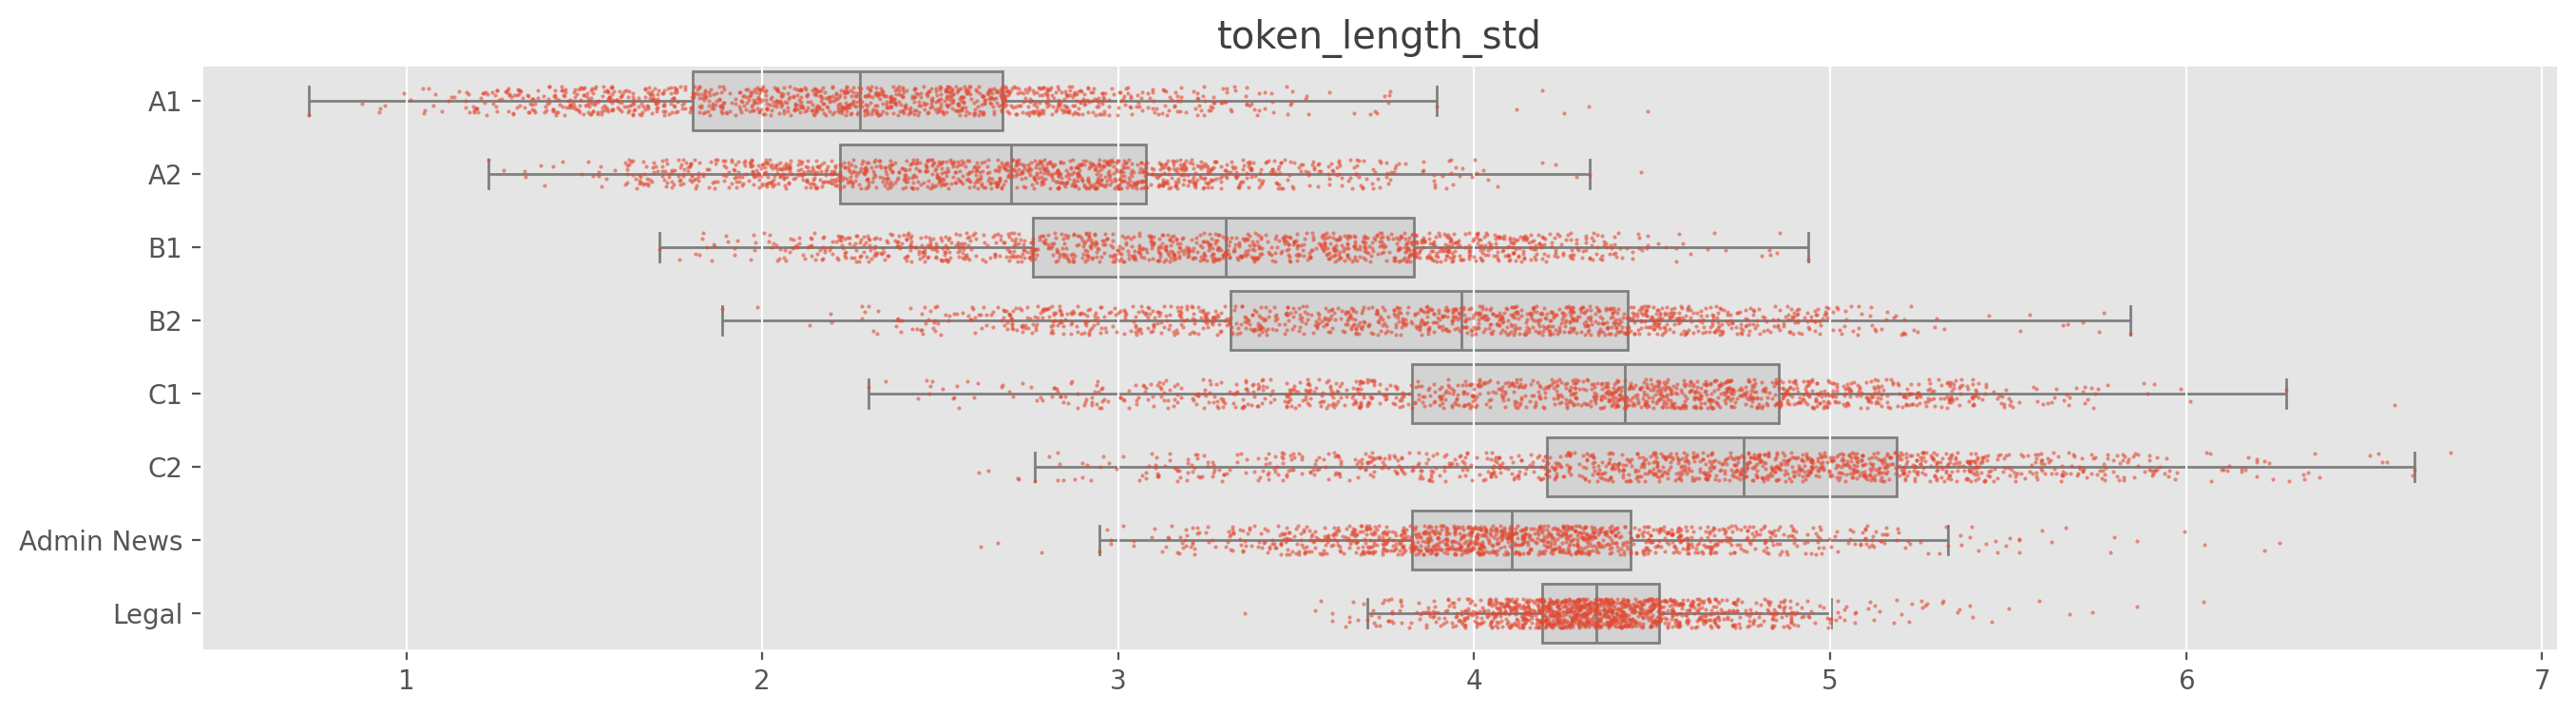

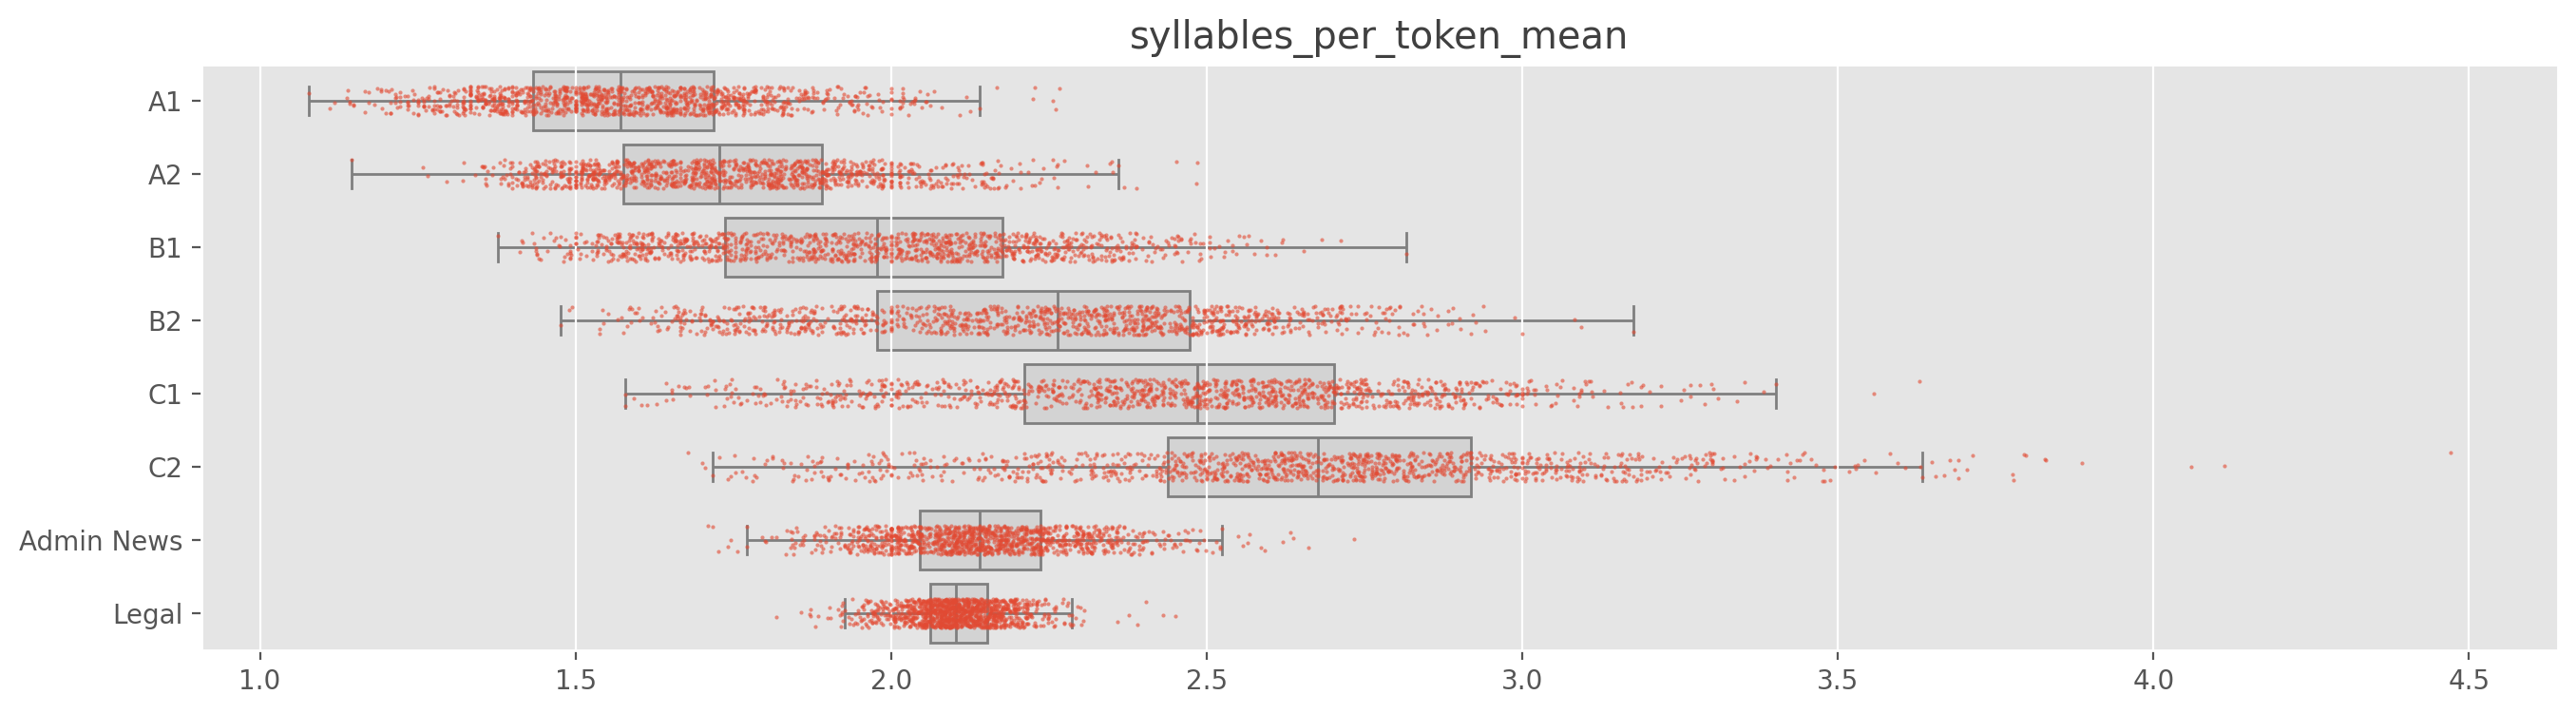

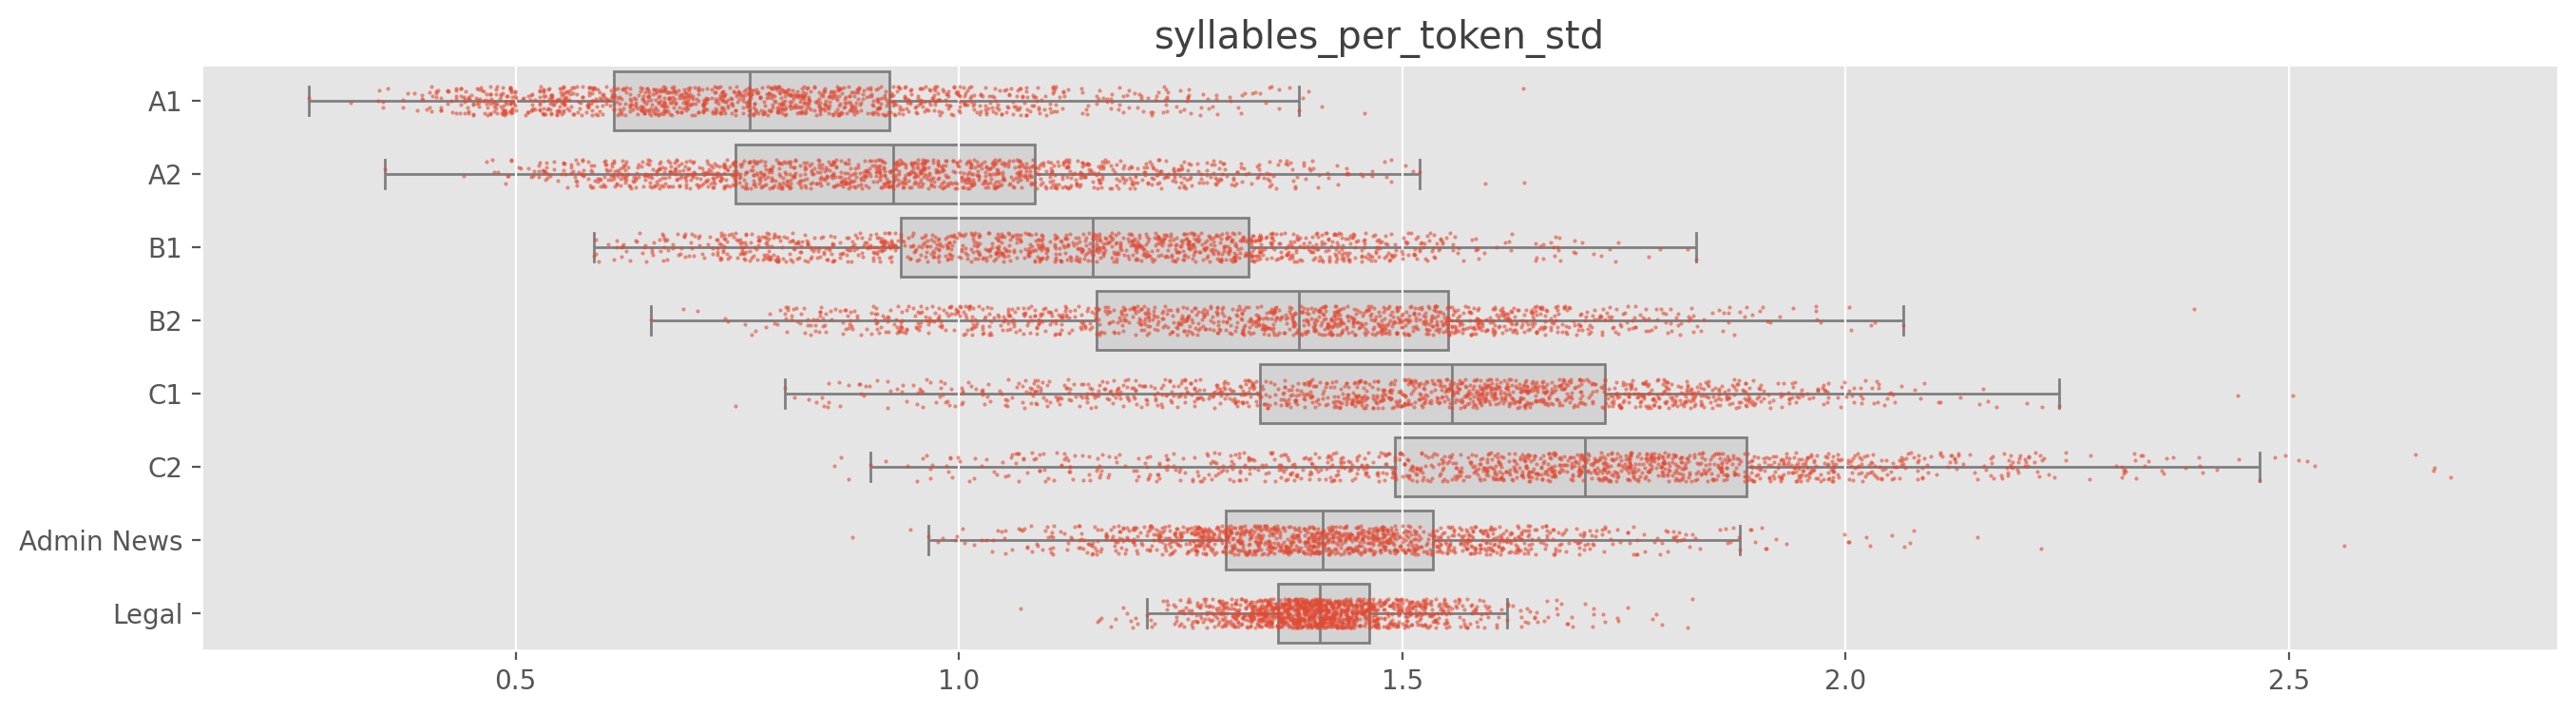

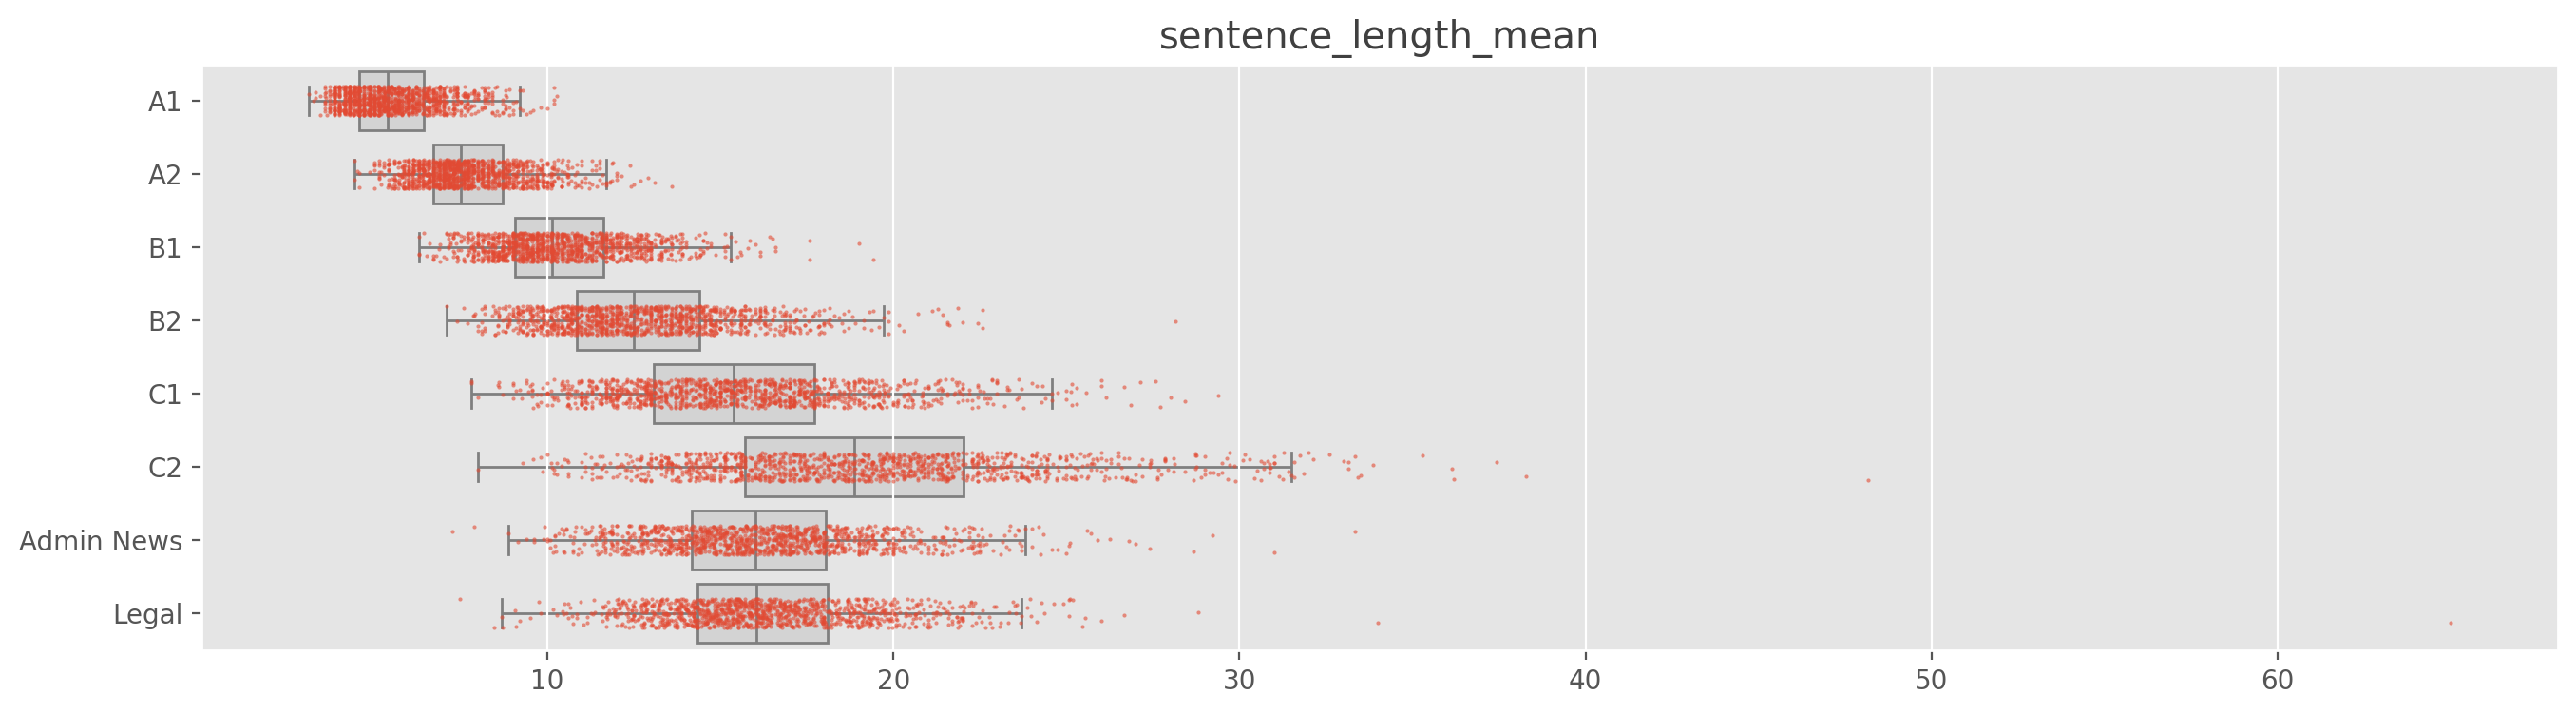

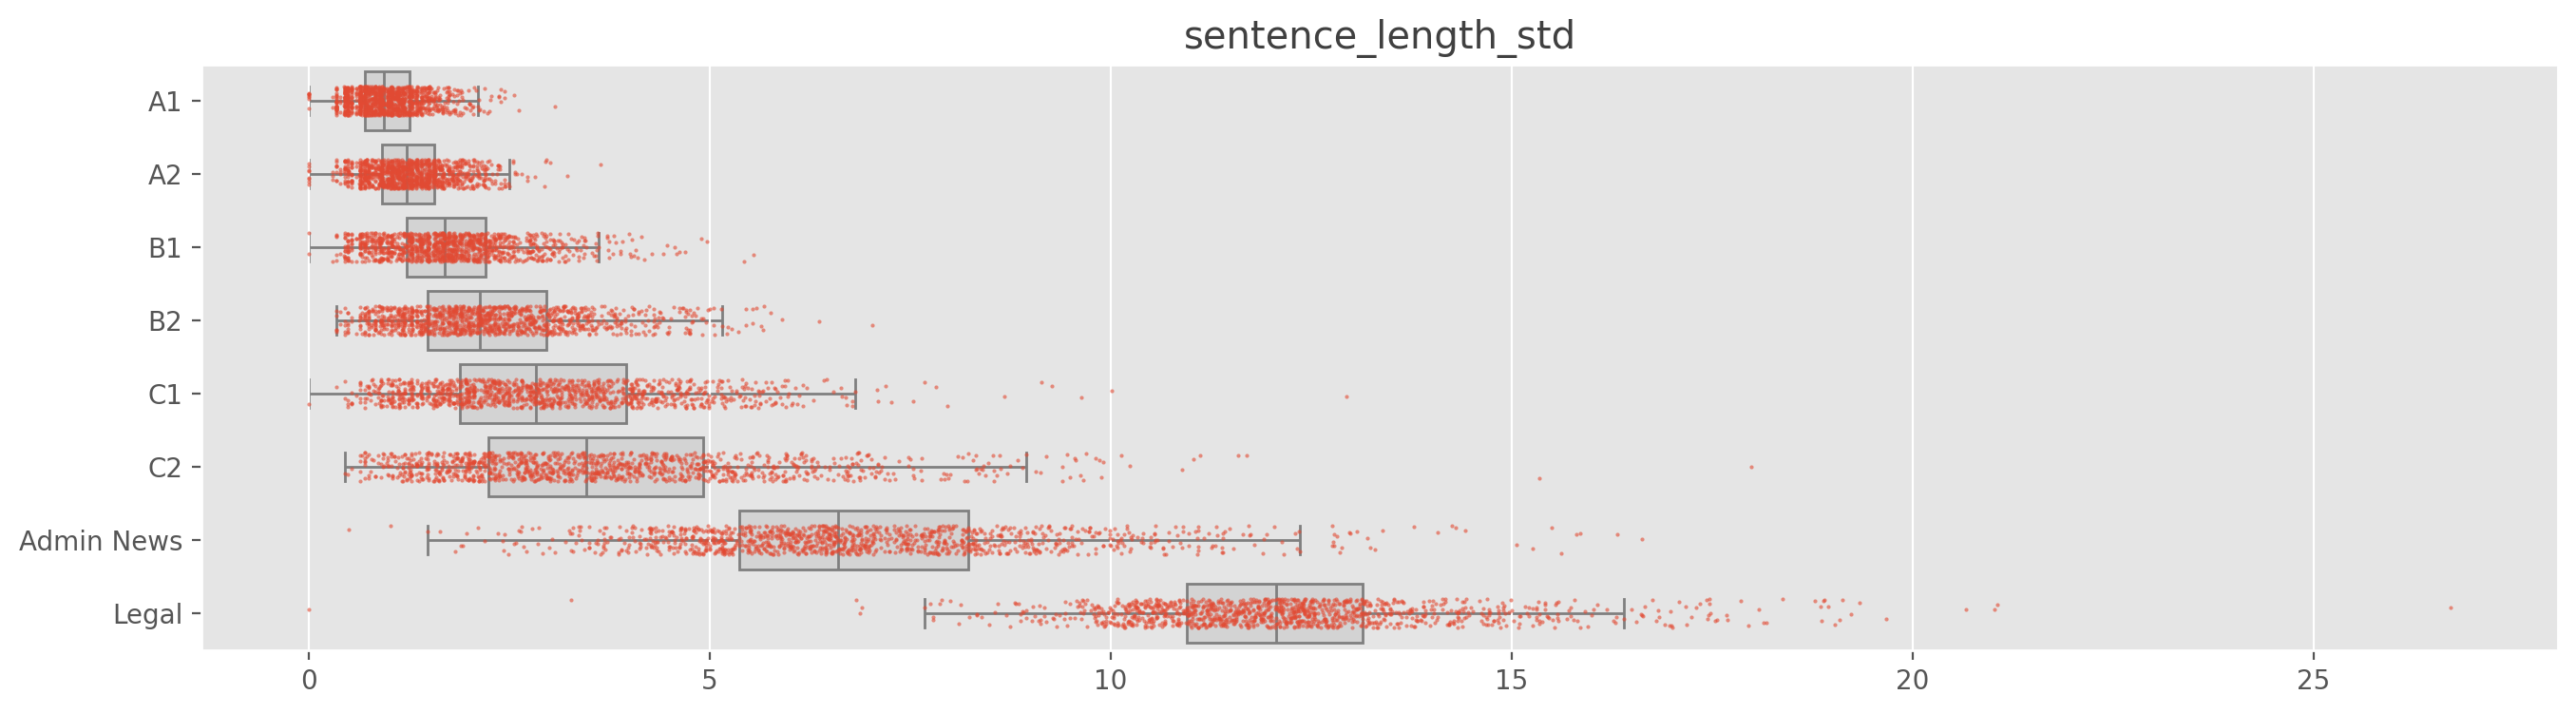

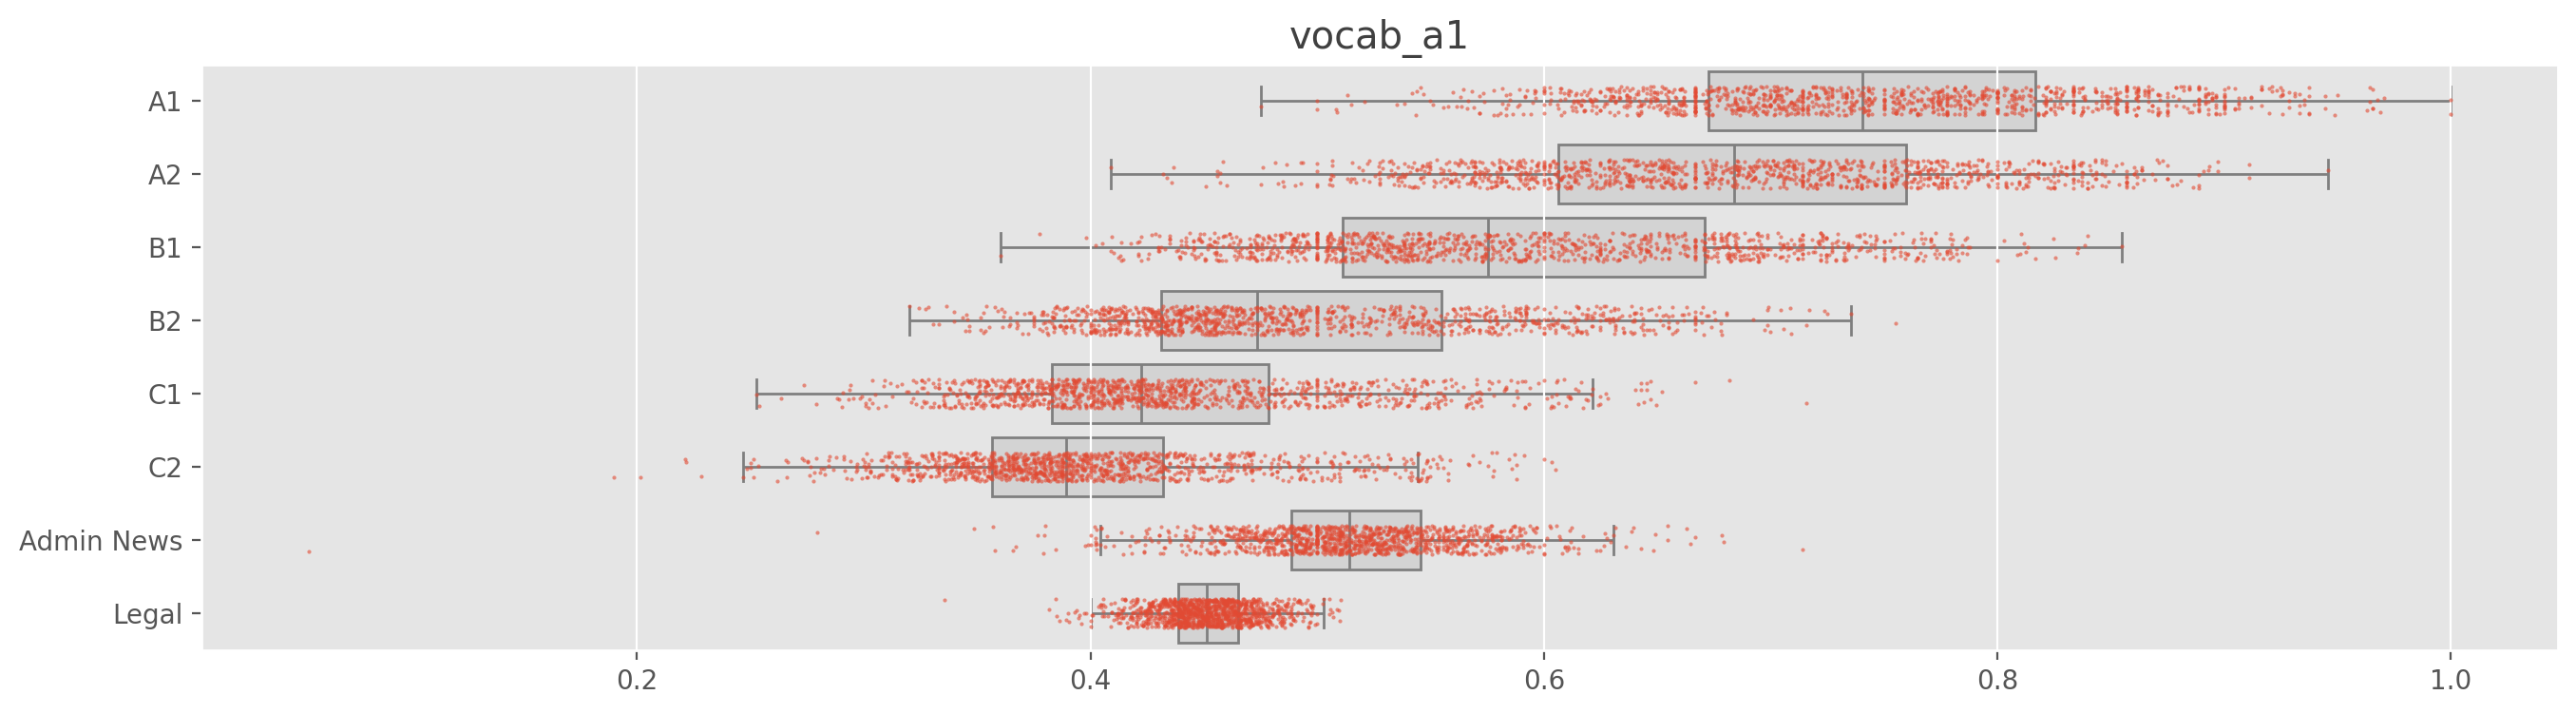

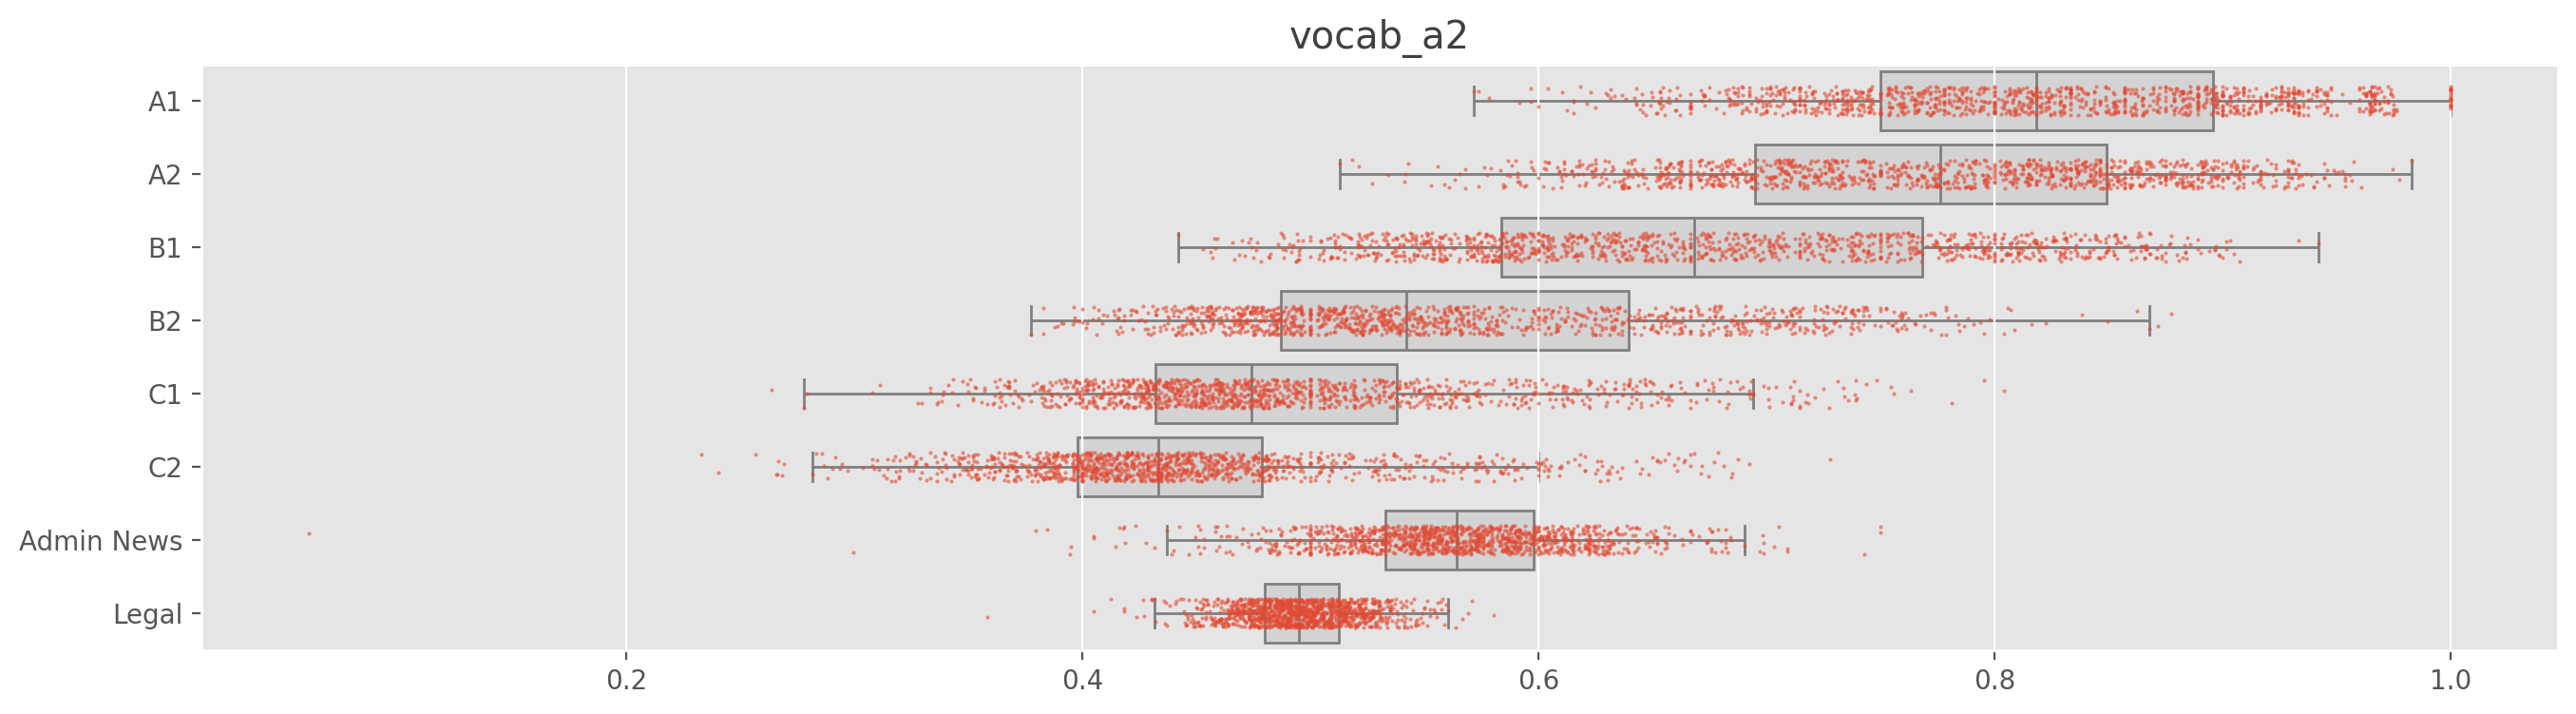

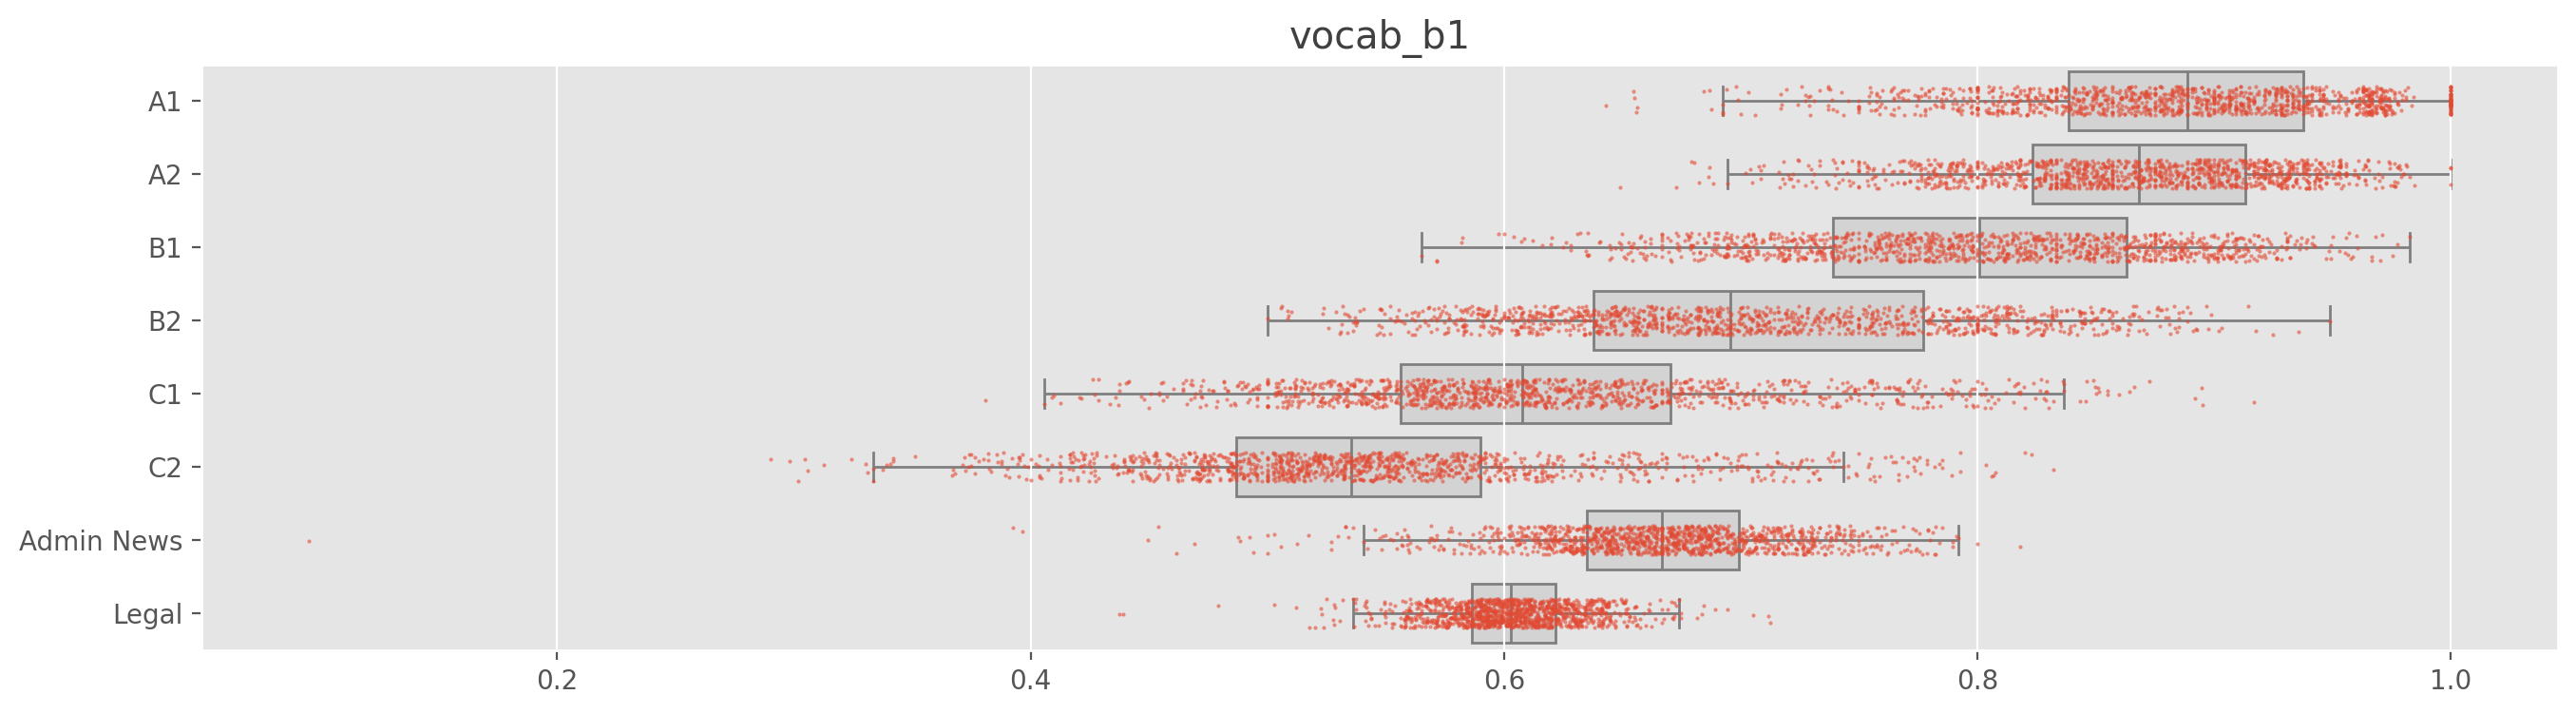

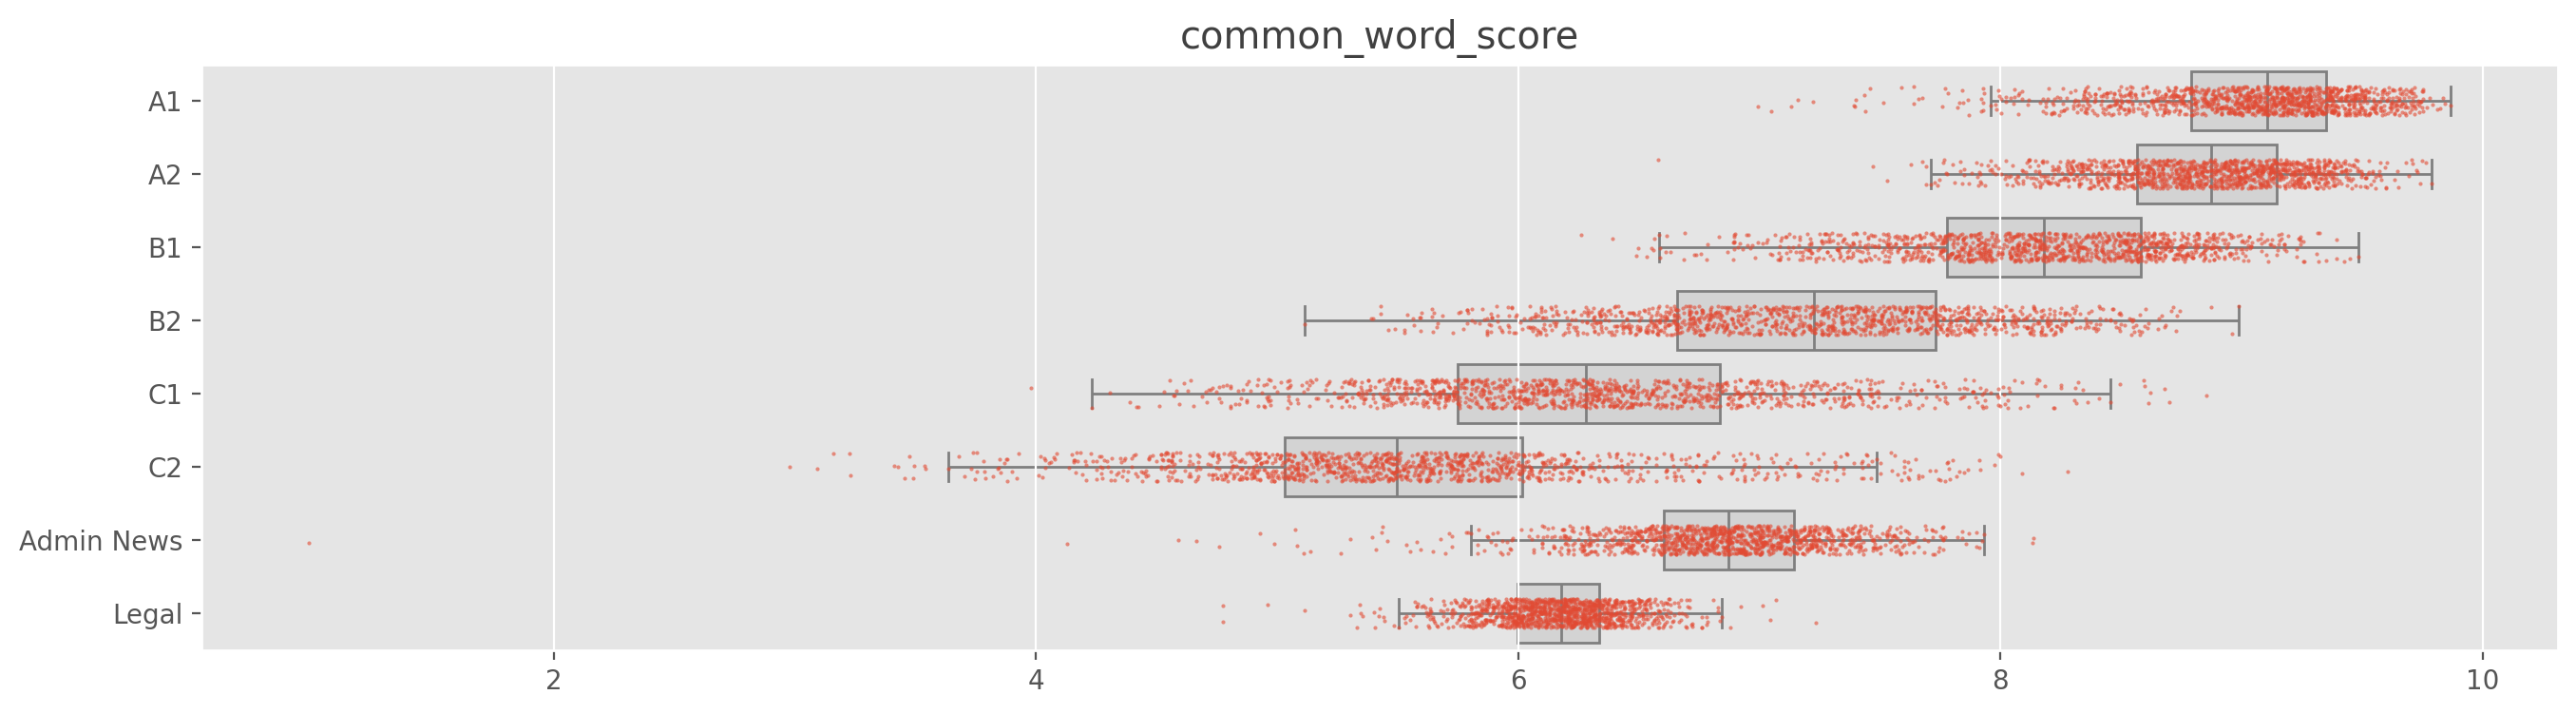

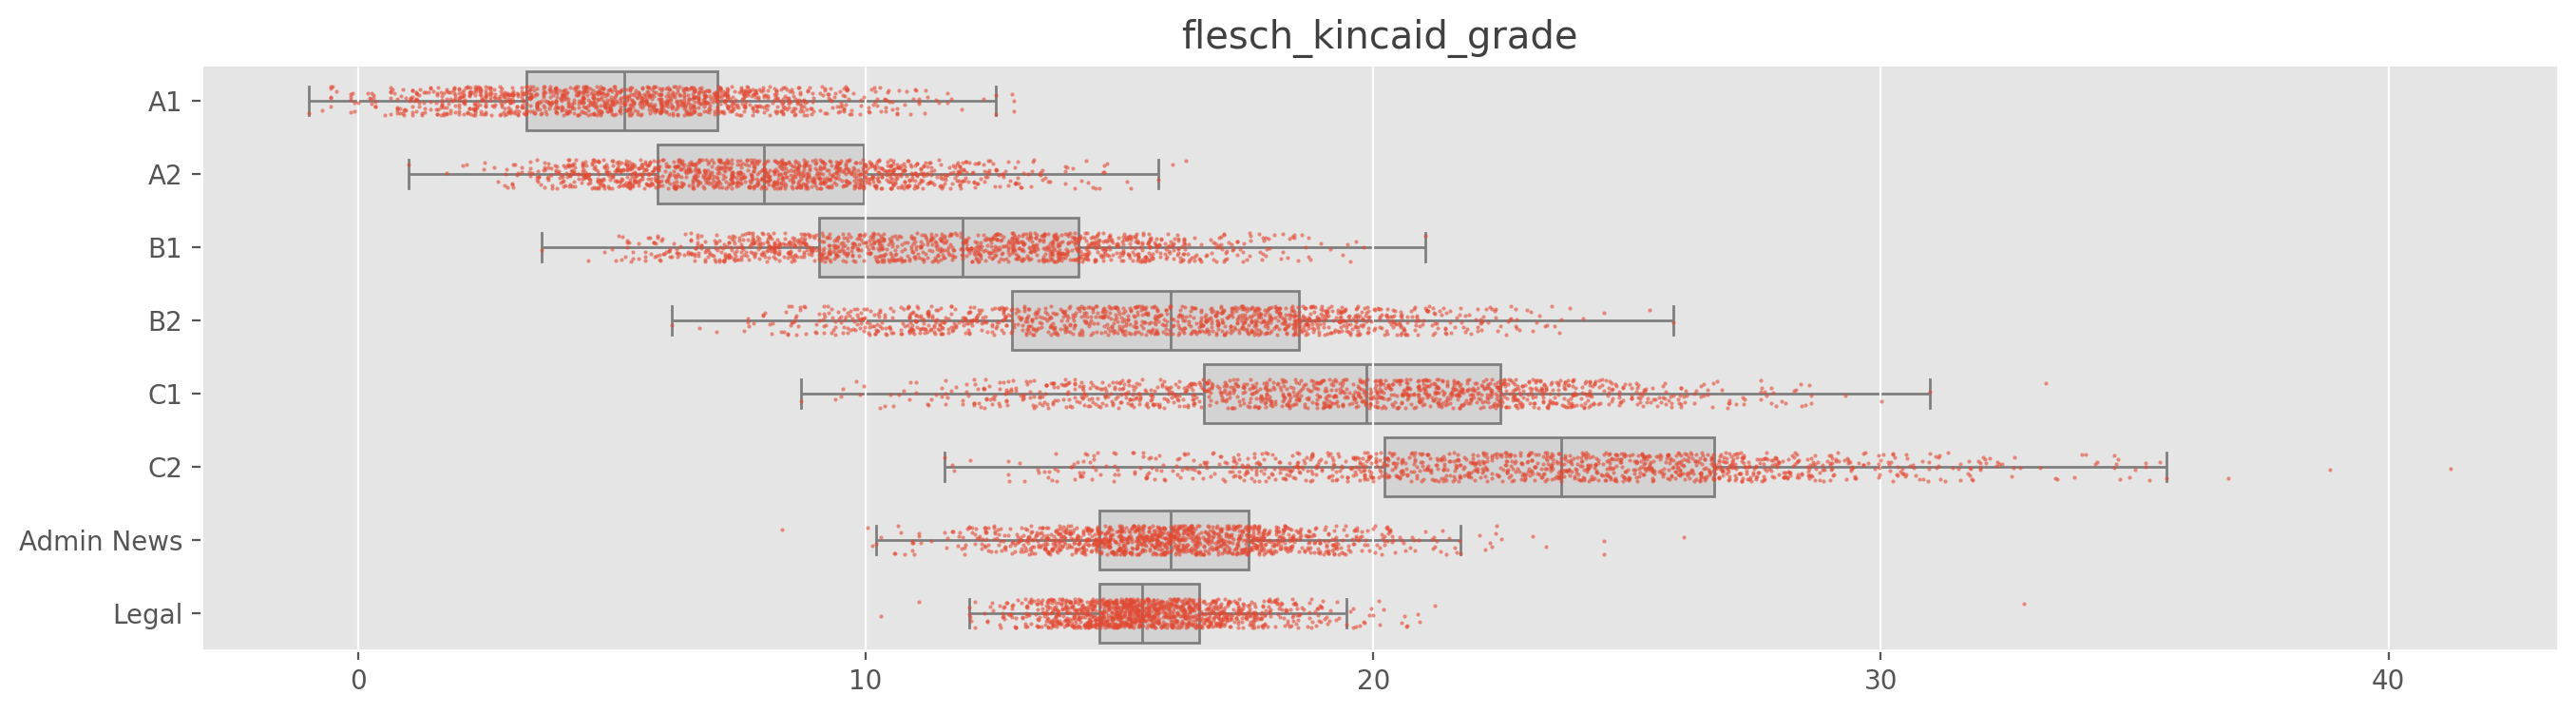

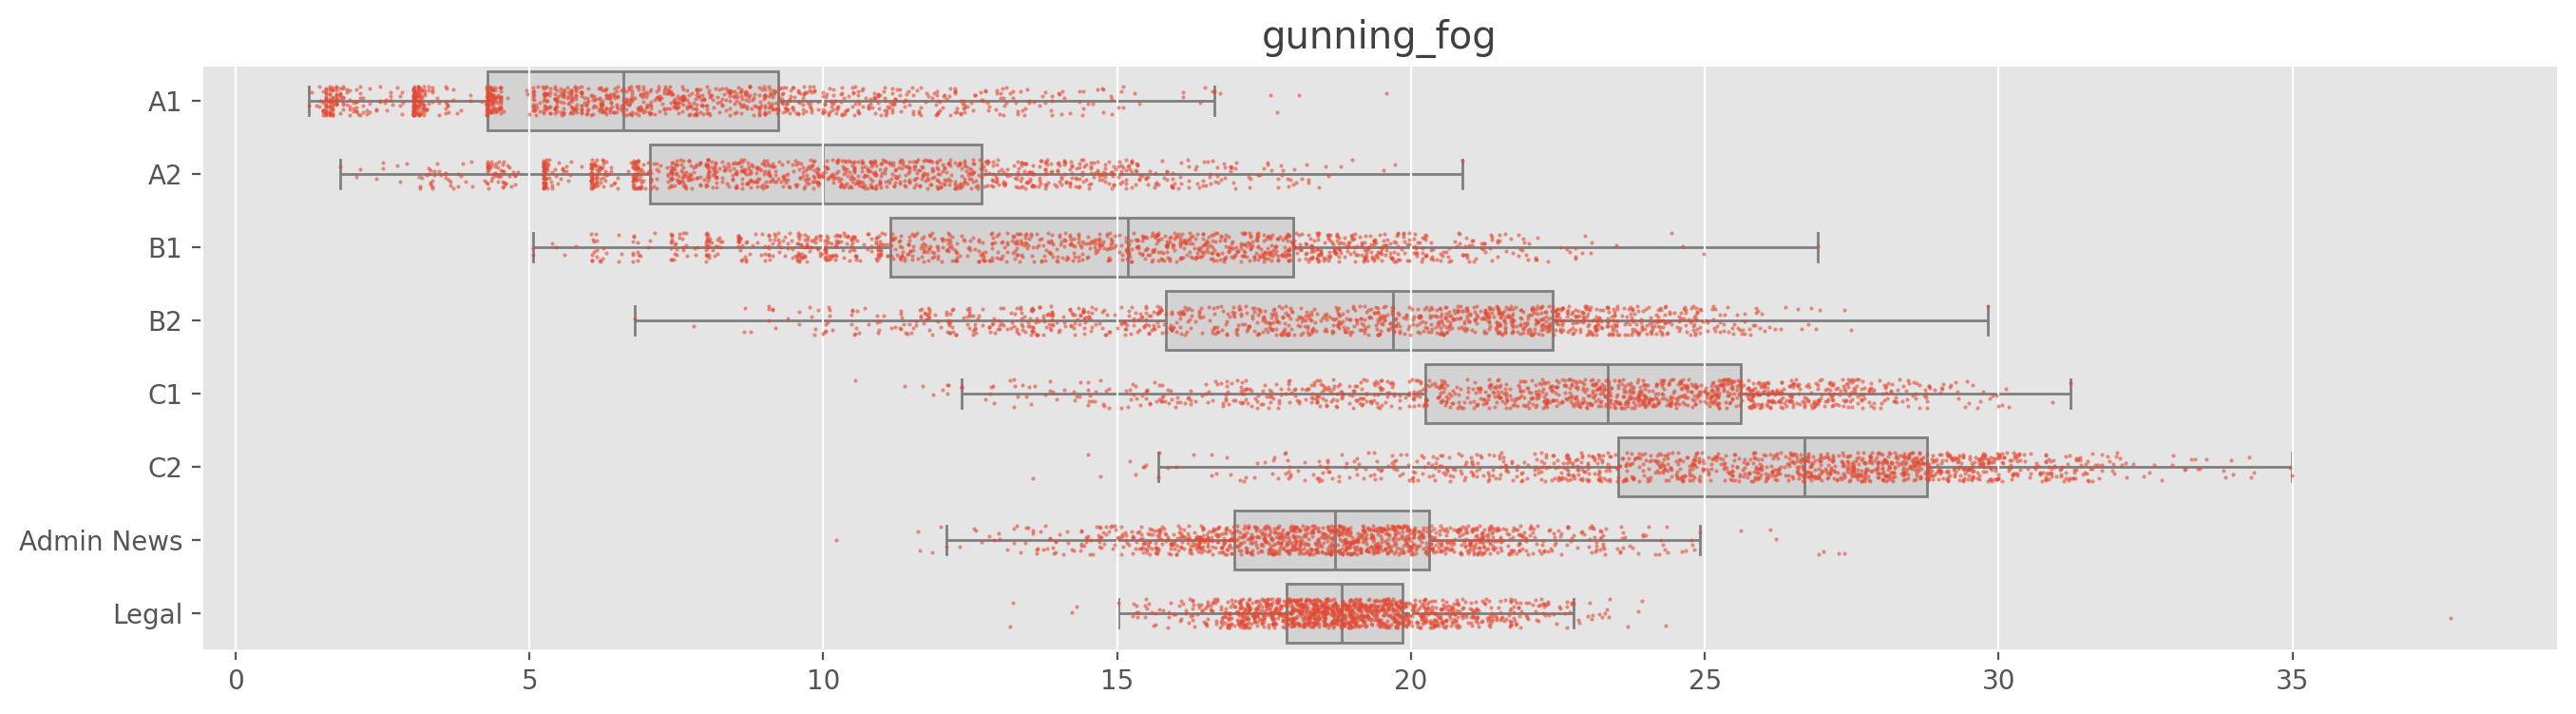

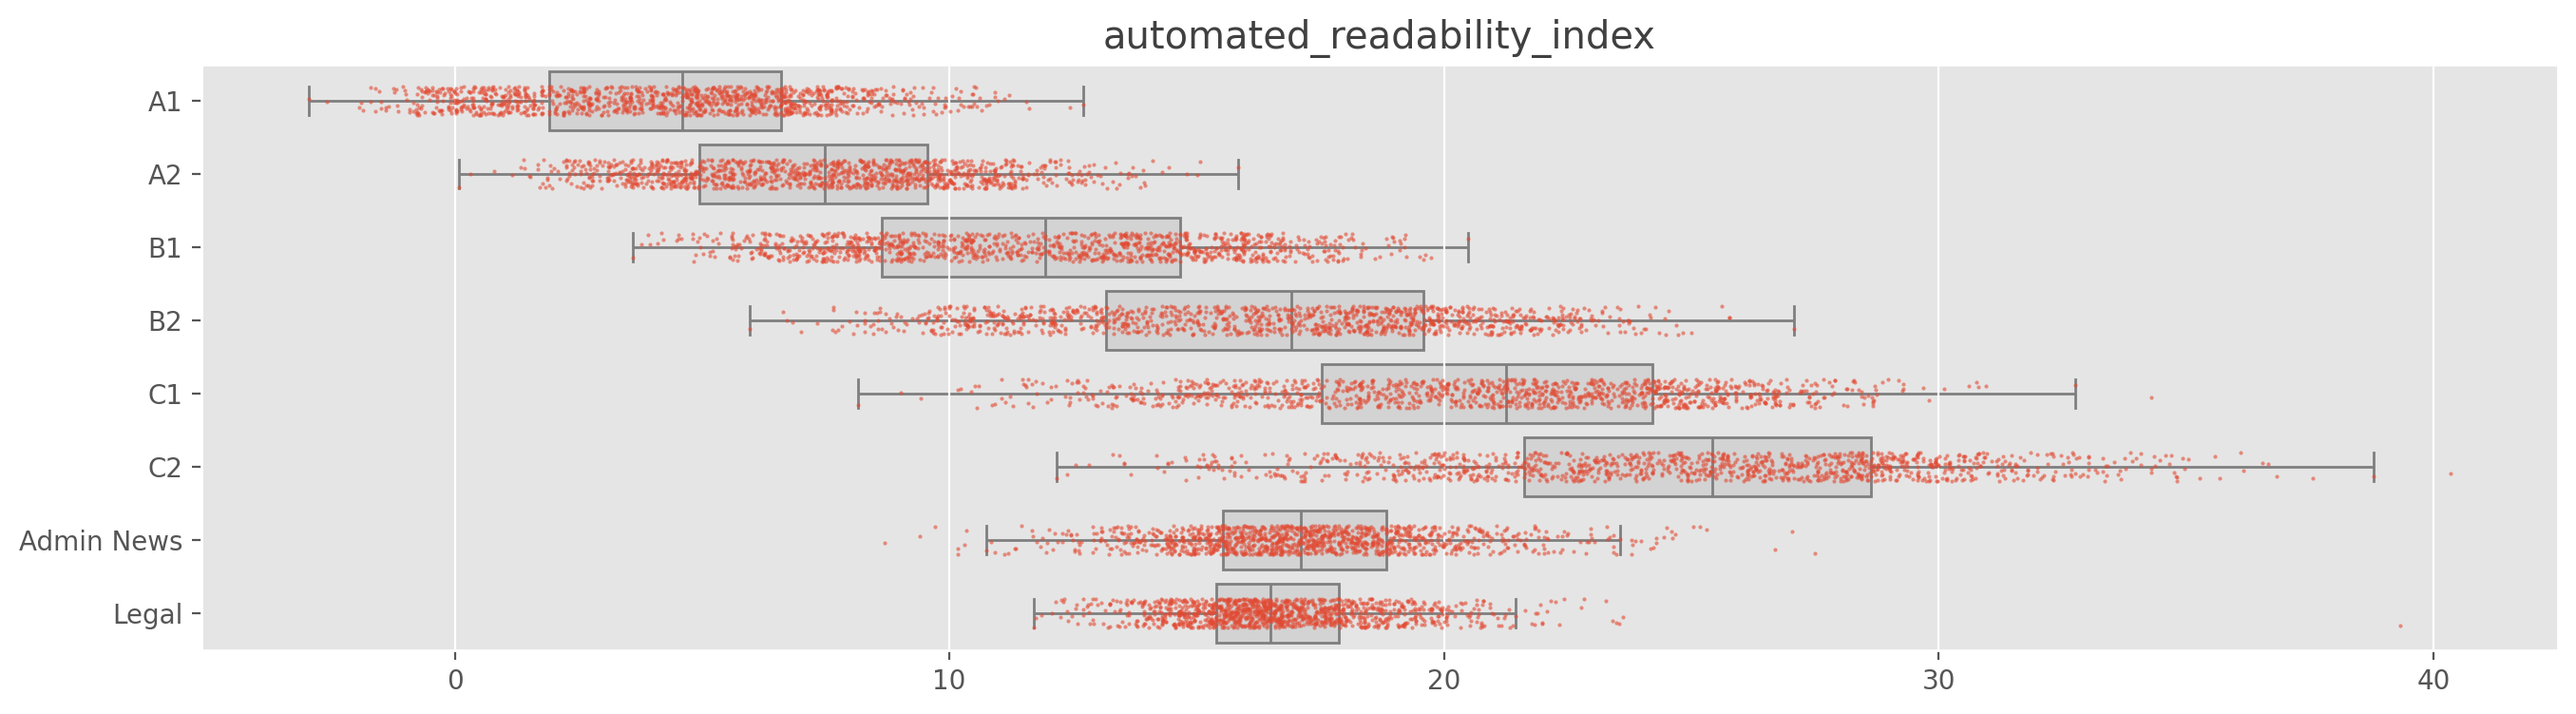

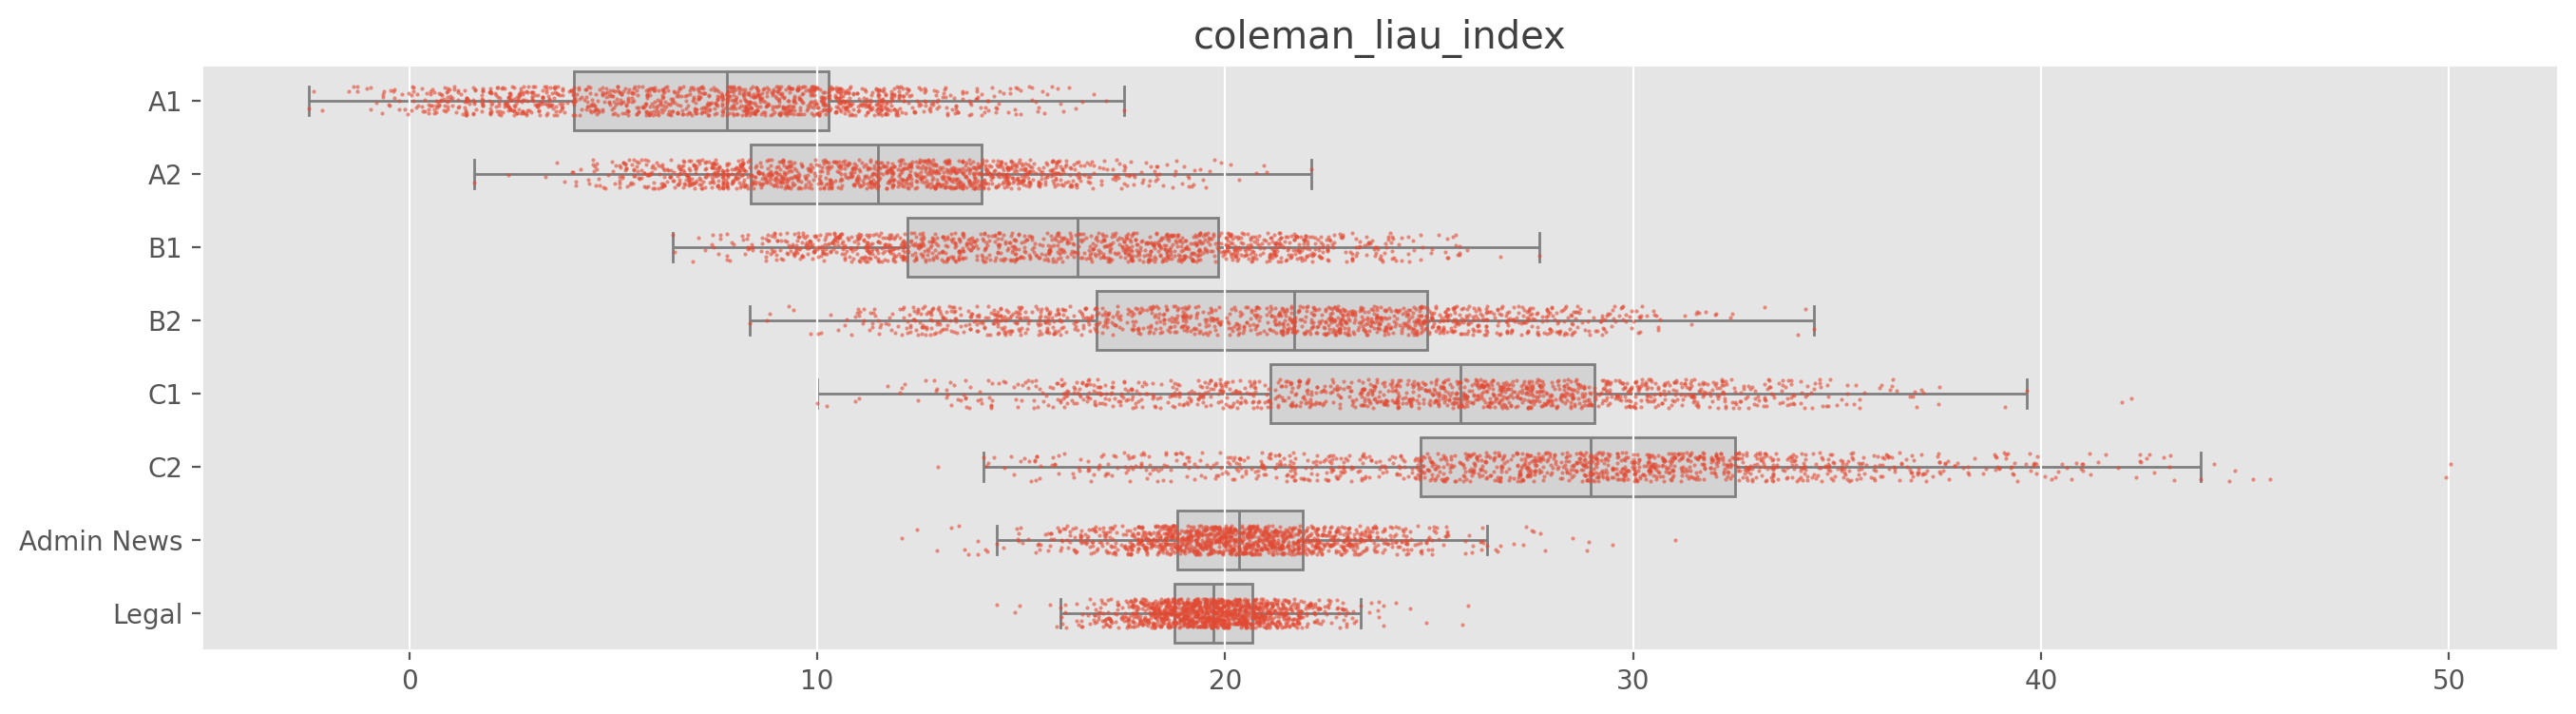

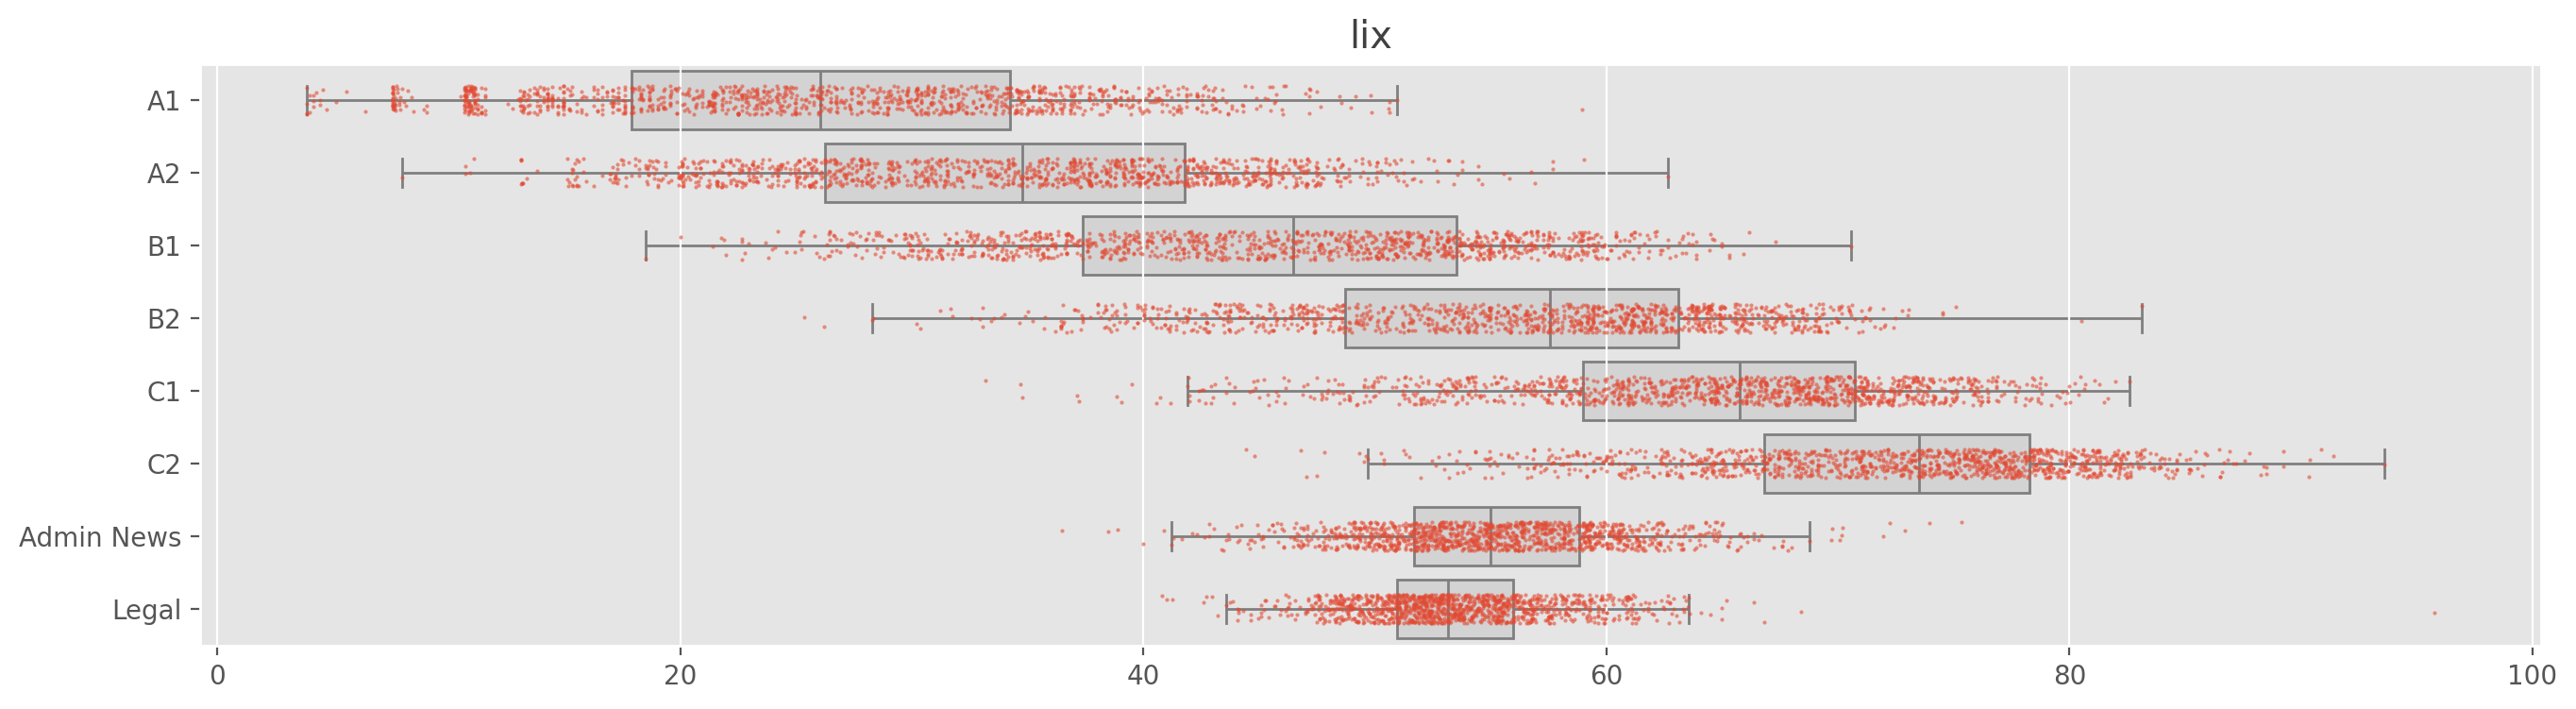

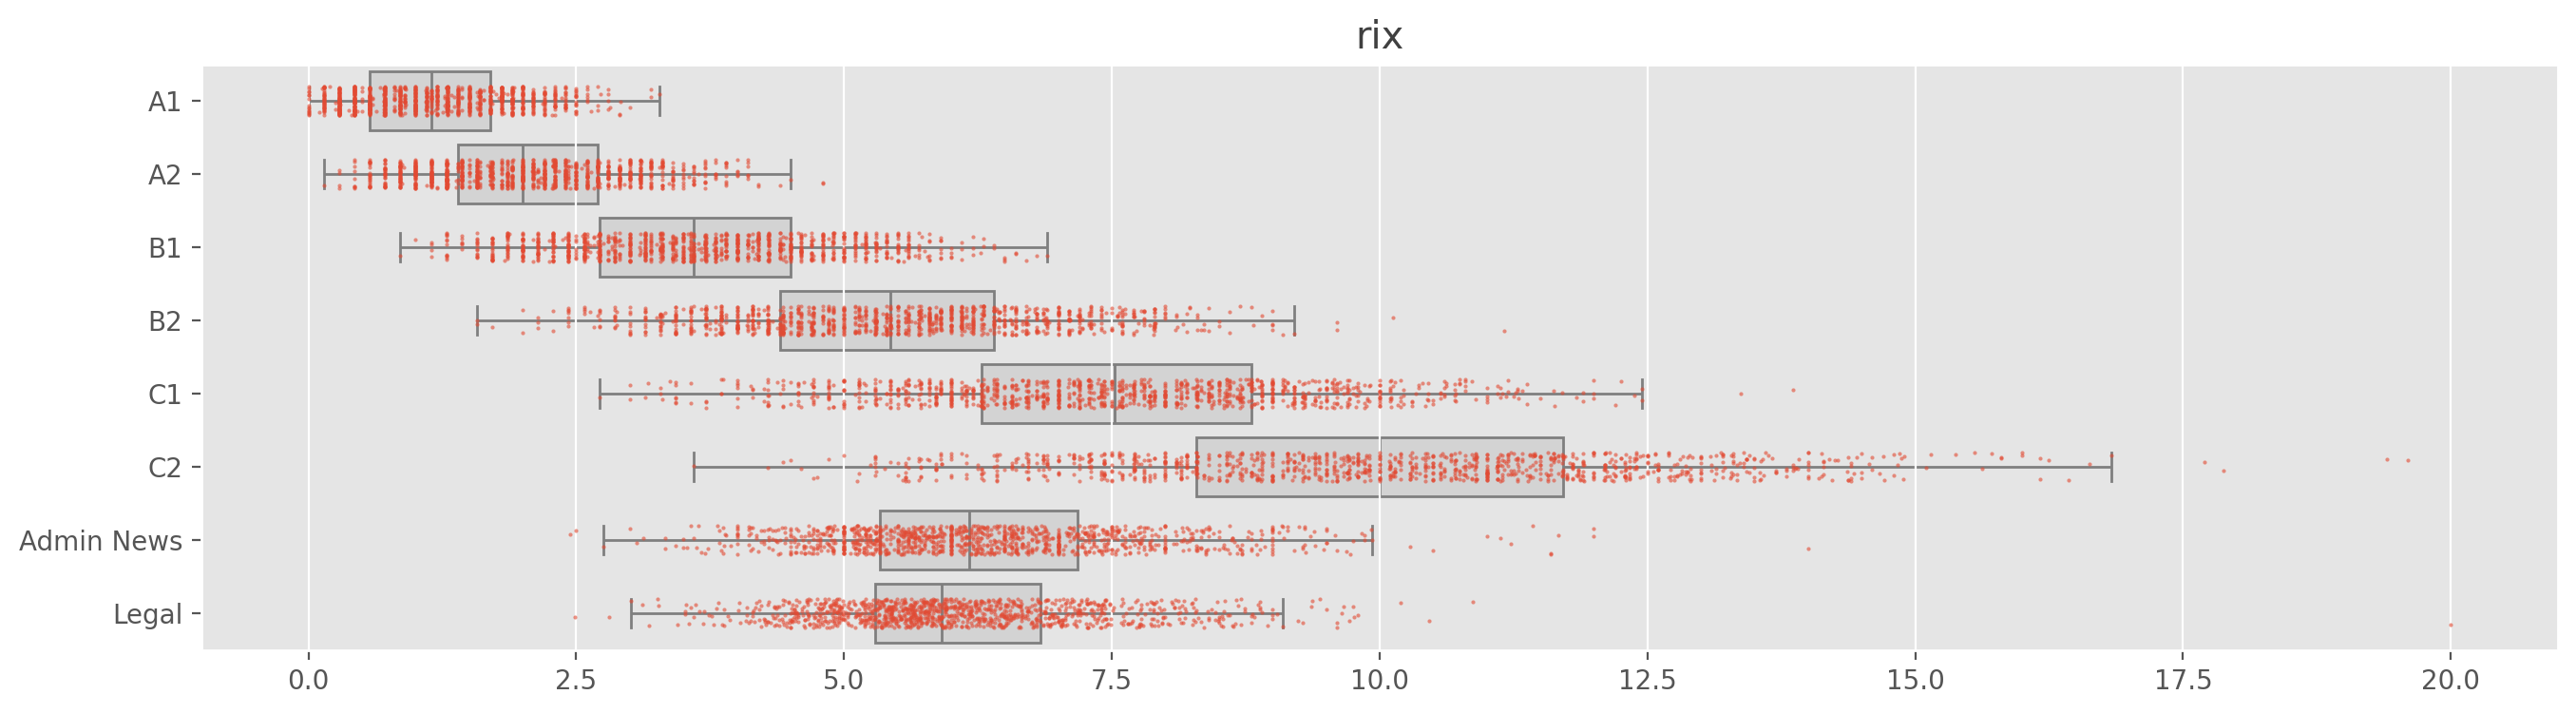

In [11]:
for col in relevant_cols:
    fig, ax = plt.subplots(figsize=(16, 4))
    sns.boxplot(
        data=df,
        x=col,
        y="text_type",
        color="lightgray",
        linewidth=1,
        ax=ax,
        order=order,
        zorder=0,
        orient="h",
        showfliers=False,
    )
    sns.stripplot(
        data=df,
        x=col,
        y="text_type",
        jitter=0.2,
        alpha=0.6,
        s=1.5,
        order=order,
        zorder=1,
        ax=ax,
        orient="h",
    )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.show()

# Model data


Our intuition is that by combining syntactic as well as semantic features, we might be able to get a sensible metric. We therefore choose a subset of apparently expressive features (2 syntactic, 4 semantic).


In [12]:
final_cols = [
    "sentence_length_mean",
    "rix",
    "vocab_a1",
    "vocab_a2",
    "vocab_b1",
    "common_word_score",
]

Now we map our text types to a regression target value according to the assumed language levels. This again involves educated guesses. We do not have ground truth here.

- We map the CEFR levels of our synthetic samples to a scale from 1 to 6.
- We assume that administrative news are of level C1.
- We assume that our legal texts are more difficult than C2 synthetic samples and assign a difficulty value of 8.

In [13]:
mapping = {
    "A1": 1,
    "A2": 2,
    "B1": 3,
    "B2": 4,
    "C1": 5,
    "Admin News": 5,
    "C2": 6,
    "Legal": 8,
}

df["difficulty"] = df.text_type.map(mapping)

Let's first model the data with a [Gaussian Mixture Model](https://scikit-learn.org/stable/modules/mixture.html#gaussian-mixture-models) so that we can identify outliers.

The idea for this stems from [Vincent Warmerdam's](https://koaning.io/) several talks and tutorials, most specifically from this live coding session [«Expanding on GMMs»](https://www.youtube.com/watch?v=821aPPsFPsY).


In [14]:
# Assess optimal number of GMM components with BIC.
n_components_range = range(5, 25, 1)
bic_scores = []
for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(df[final_cols])
    bic_scores.append(gmm.bic(df[final_cols]))

optimal_n = n_components_range[np.argmin(bic_scores)]
print(f"Optimal number of components: {optimal_n}")

Optimal number of components: 13


In [15]:
optimal_n = 13
gmm = GaussianMixture(n_components=optimal_n, random_state=42)
gmm.fit(df[final_cols])
df["log_likelihood"] = gmm.score_samples(df[final_cols])

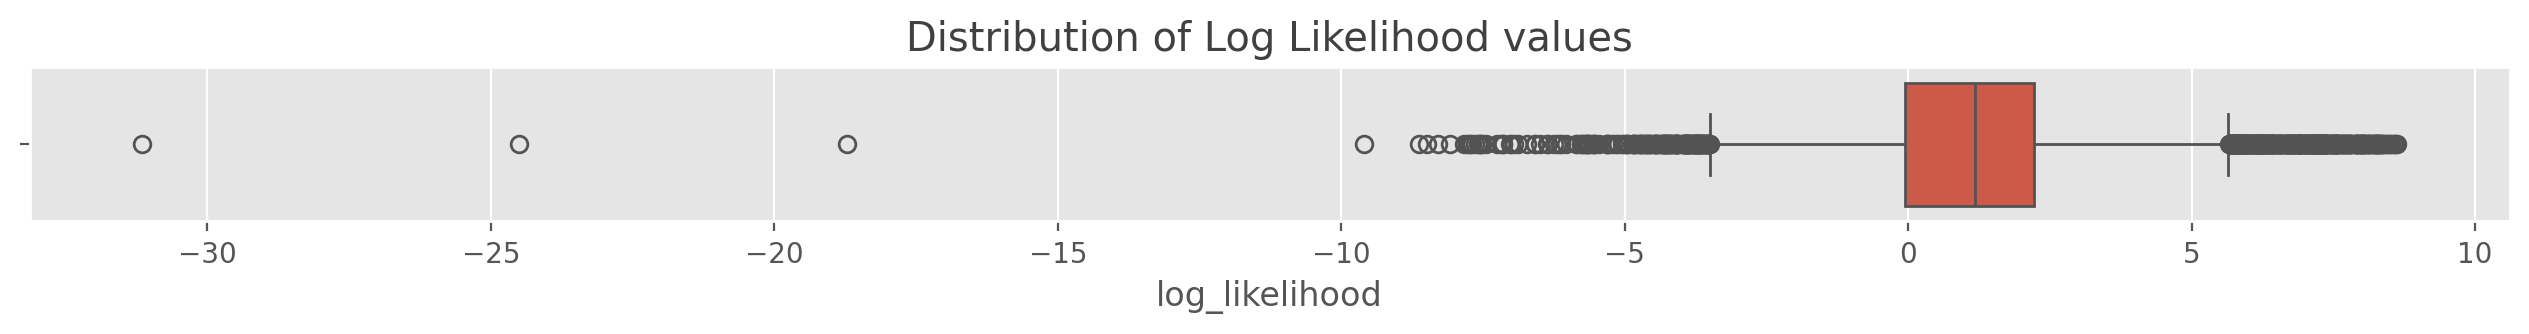

In [16]:
fig, ax = plt.subplots(figsize=(16, 1))
sns.boxplot(data=df, x="log_likelihood", showfliers=True)
ax.set_title("Distribution of Log Likelihood values")
plt.show()

In [17]:
def detect_outliers_by_text_type(df, feature_cols, method="iqr", factor=1.5):
    """
    Detect outliers separately for each text type.

    Parameters:
    -----------
    method : str
        'iqr' or 'std'
    factor : float
        For IQR: multiplier for IQR (1.5 = mild, 3.0 = extreme)
        For std: number of standard deviations (2 or 3)
    """
    outlier_mask = pd.Series(False, index=df.index)

    for text_type in df["text_type"].unique():
        mask = df["text_type"] == text_type
        text_type_df = df[mask]

        # Find optimal number of components for this text type
        n_components_range = range(1, 10, 1)
        bic_scores = []
        for n in n_components_range:
            gmm = GaussianMixture(n_components=n, random_state=42)
            gmm.fit(text_type_df[feature_cols])
            bic_scores.append(gmm.bic(text_type_df[feature_cols]))

        optimal_n = n_components_range[np.argmin(bic_scores)]
        print(f"{text_type}: Optimal n_components = {optimal_n}")

        # Fit GMM for this text type
        gmm = GaussianMixture(
            n_components=optimal_n, random_state=42
        )
        gmm.fit(text_type_df[feature_cols])
        ll = gmm.score_samples(text_type_df[feature_cols])

        if method == "iqr":
            Q1 = np.percentile(ll, 25)
            Q3 = np.percentile(ll, 75)
            IQR = Q3 - Q1
            threshold = Q1 - factor * IQR
        elif method == "std":
            threshold = ll.mean() - factor * ll.std()

        # Mark outliers for this text type
        text_type_outliers = ll < threshold
        outlier_mask[text_type_df.index[text_type_outliers]] = True

        print(
            f"{text_type}:\t {text_type_outliers.sum()} outliers ({text_type_outliers.sum() / len(ll) * 100:.1f}%)"
        )

    return outlier_mask


# Apply text-type-specific detection
outlier_mask = detect_outliers_by_text_type(
    df, final_cols, method="iqr", factor=1.5
)

df["is_outlier"] = outlier_mask
df_outlier = df[df["is_outlier"]]
df_inlier = df[~df["is_outlier"]]

print(f"\nTotal outliers: {len(df_outlier)} ({len(df_outlier) / len(df) * 100:.1f}%)")

Legal: Optimal n_components = 3
Legal:	 35 outliers (2.9%)
C2: Optimal n_components = 3
C2:	 36 outliers (3.0%)
C1: Optimal n_components = 2
C1:	 19 outliers (1.6%)
B1: Optimal n_components = 2
B1:	 38 outliers (3.2%)
A2: Optimal n_components = 2
A2:	 37 outliers (3.1%)
A1: Optimal n_components = 4
A1:	 33 outliers (2.8%)
Admin News: Optimal n_components = 2
Admin News:	 26 outliers (2.2%)
B2: Optimal n_components = 2
B2:	 37 outliers (3.1%)

Total outliers: 261 (2.7%)


We check the most extreme outliers according to our GMM modeling.


In [18]:
for text, text_type, score in (
    df_outlier.sort_values("log_likelihood", ascending=True)[
        ["text", "text_type", "log_likelihood"]
    ]
    .head(3)
    .values
):
    print(f"Type: {text_type} - log_likelihood: {score:.2f}")
    print(text[:1000])
    print("\n")

Type: Legal - log_likelihood: -31.15
BRKE II Nr. 142/1999 vom 17. August 1999 in BEZ 1999 Nr. 40. Zulässig und damit rekursweise anfechtbar sind nicht drittverbindliche Vorentscheide hingegen, soweit sie sich mit Vorschriften ohne raumplanerische Funktion befassen, wozu die vorwiegend technischen Normen über die baustatische Sicherheit, die Verkehrssicherheit im engsten Sinne, den Brandschutz usw., aber auch etwa die Bestimmungen über Hygiene und innere Erschliessung der Räume zu zählen sind.


Type: Admin News - log_likelihood: -24.50
Zurich is an important driver of growth for Digital Health companies. Numerous factors contribute to this standing, including Zurich’s position as a leading financial hub and as a location of choice for renowned universities and companies in the healthcare, technology and insurance industries. These are the findings of a joint analysis compiled by the Canton of Zurich and Health-Trends, a Swiss think tank for Digital Health. The results of the analysis a

Now we model the data with a Ridge Regressor using cross-validation. We use all three sets of features. We get similar results from the reduced feature set.


In [19]:
def plot_coefficients(clf, cols):
    coefficents = sorted(
        list(zip(df_inlier[cols].columns, clf.coef_)),
        key=lambda x: np.abs(x[1]),
        reverse=True,
    )
    coef = pd.DataFrame(coefficents, columns=["feature", "coefficient"])
    coef["coef_abs"] = coef.coefficient.abs()
    fig, ax = plt.subplots(figsize=(16, 7))
    sns.barplot(data=coef, x="coef_abs", y="feature", orient="h", ax=ax)
    ax.set_title("Coefficients of Ridge Regression", size=20, pad=20)
    ax.set_xlabel("Coefficient")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

Optimal alpha: 0.305
0.91 R2 score - All features


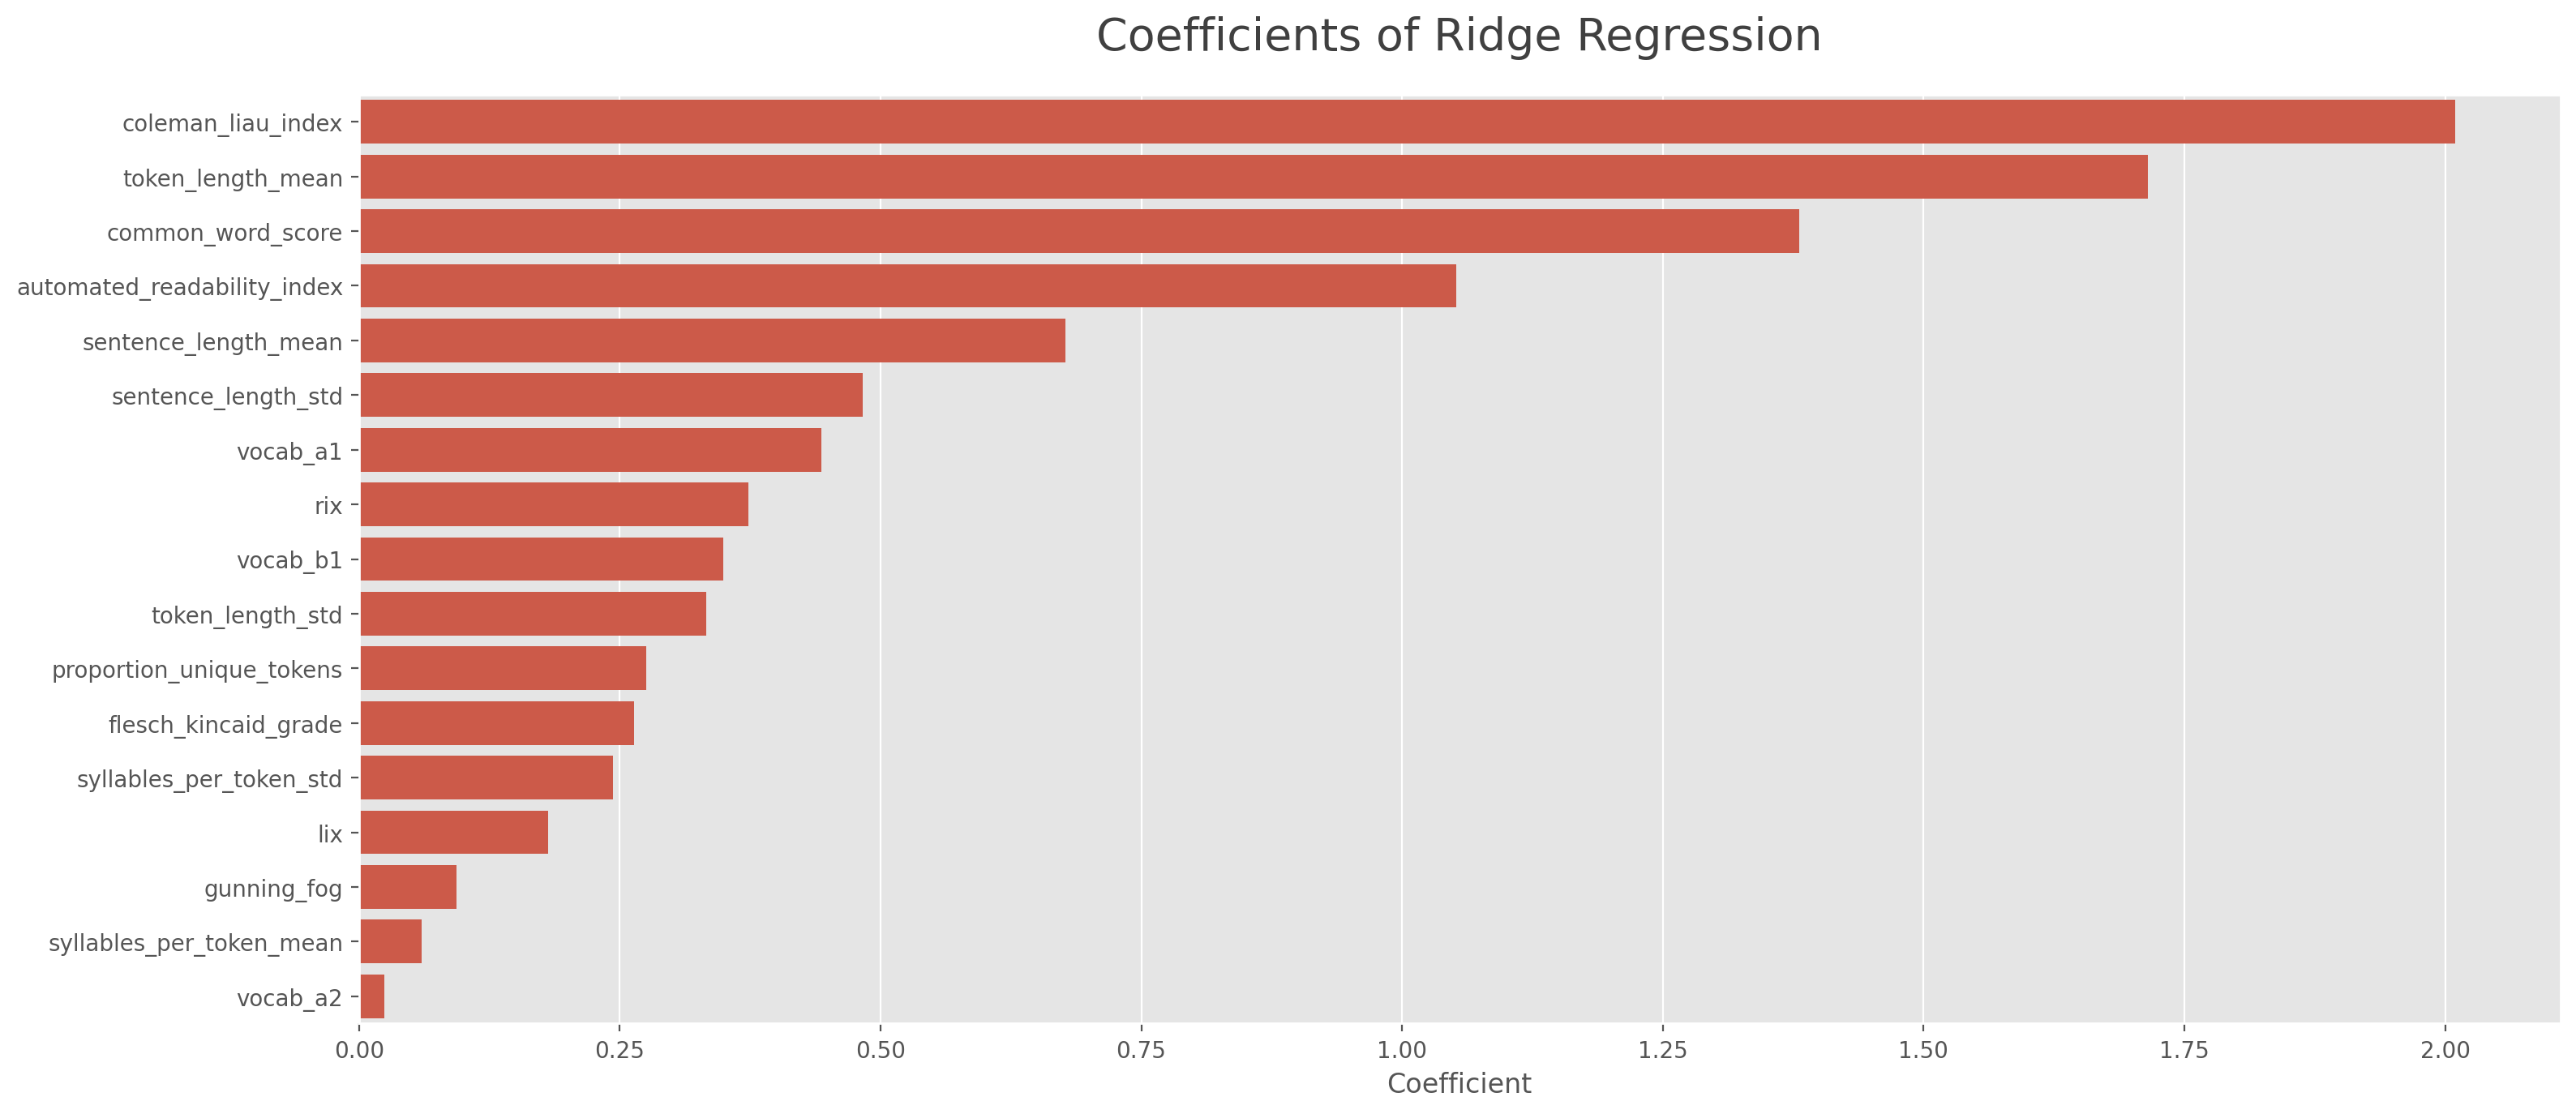

Optimal alpha: 0.175
0.85 R2 score - Subset of features


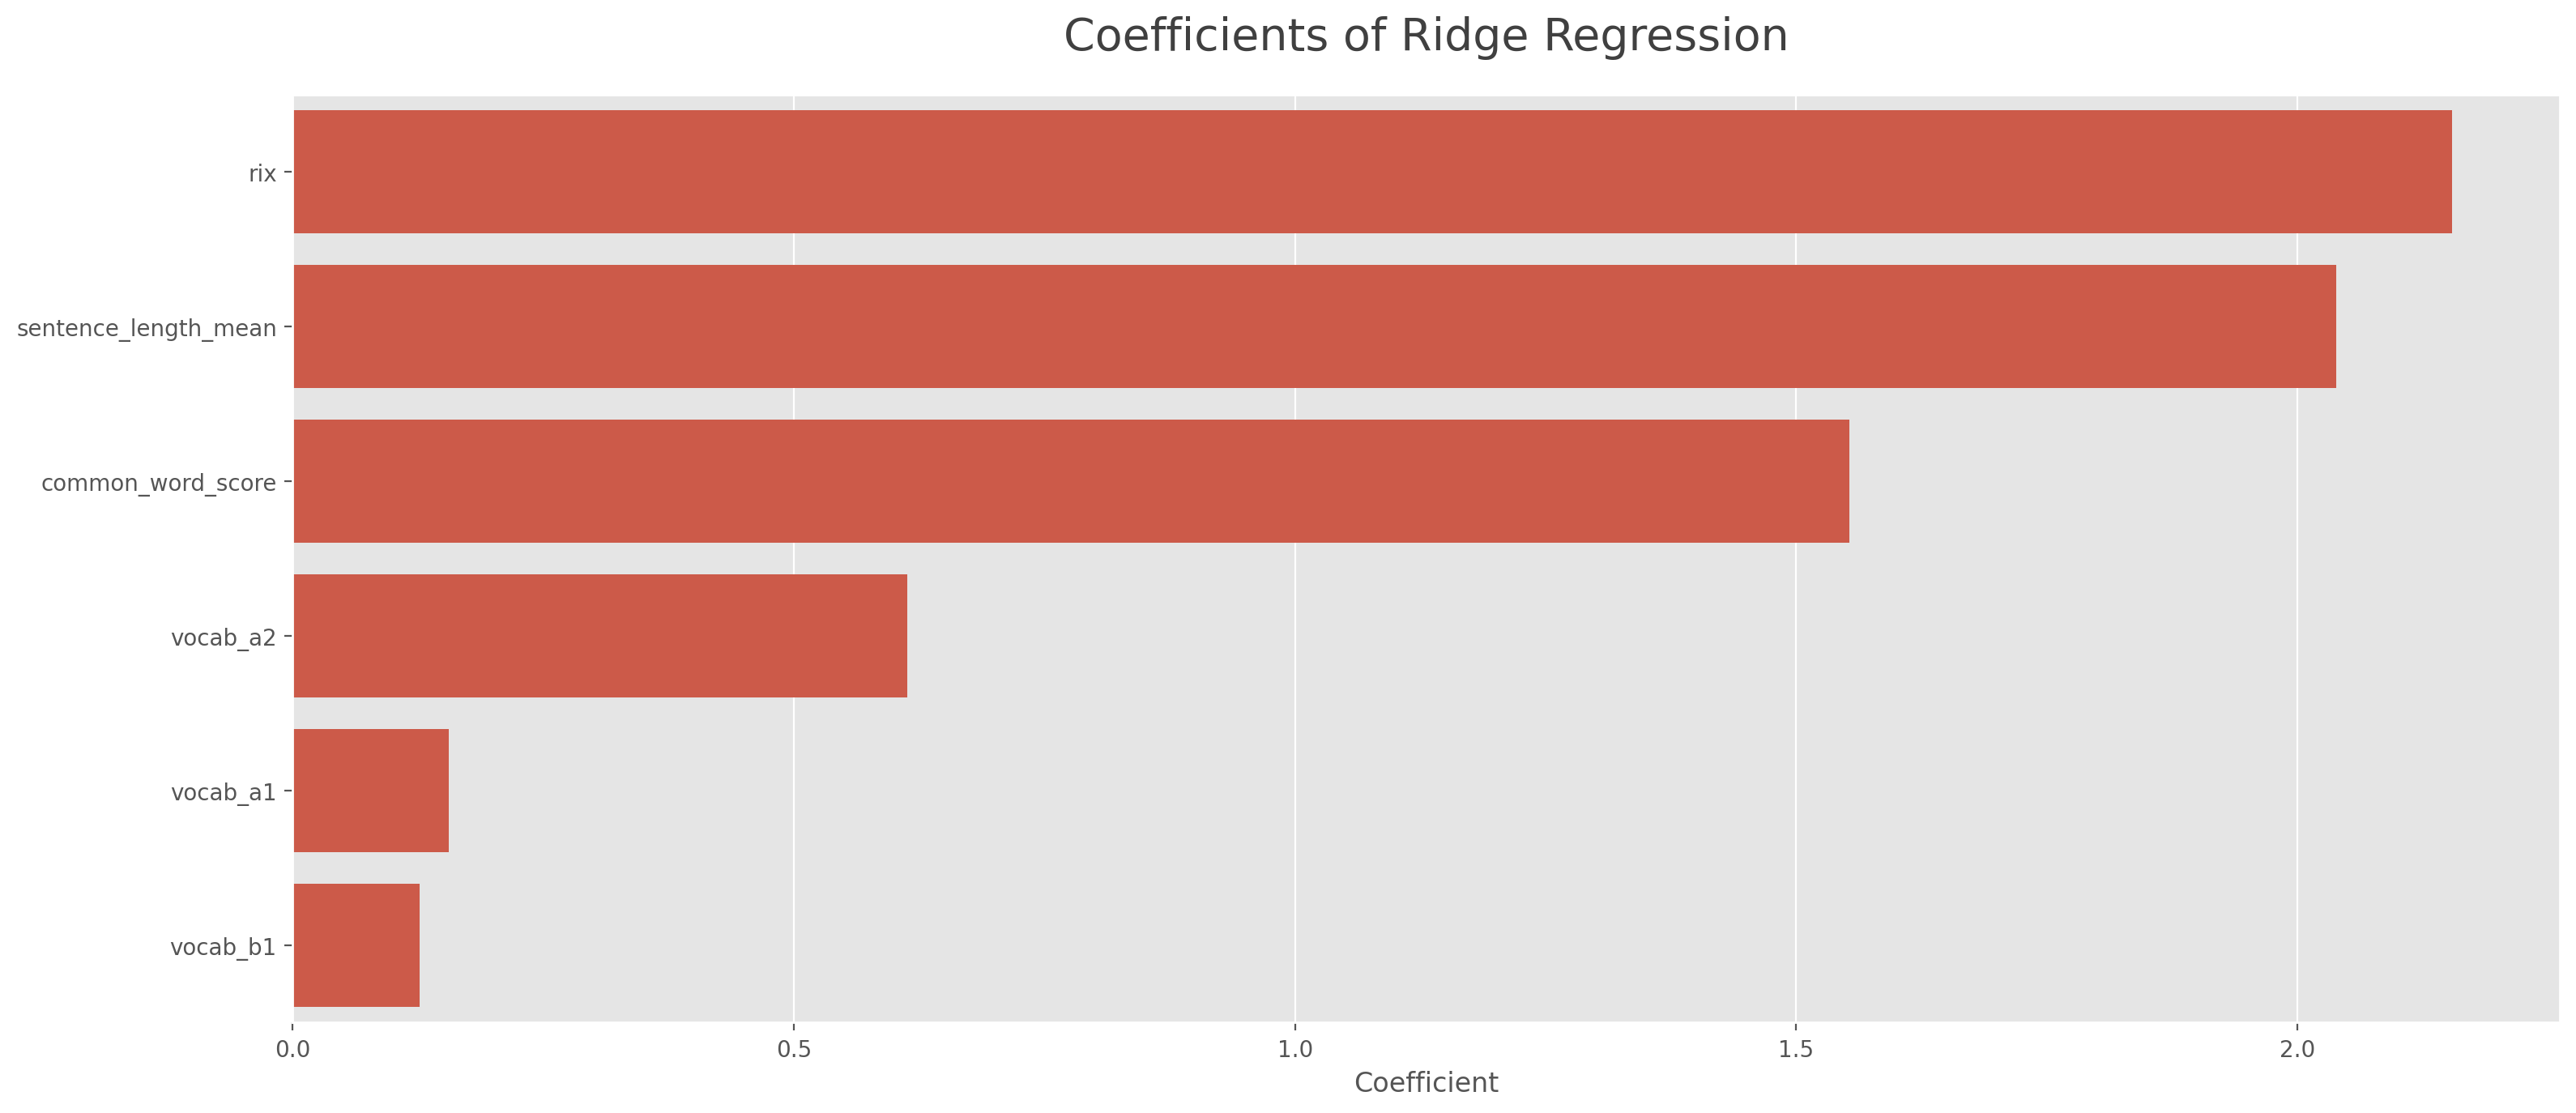

In [20]:
alphas = np.logspace(-2, 2, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=5)

for names, cols in zip(
    ["All features", "Subset of features"],
    [relevant_cols, final_cols],
):
    scaler = StandardScaler()
    X = scaler.fit_transform(df_inlier[cols])
    y = df_inlier["difficulty"]

    alphas = np.logspace(-1, 3, 100)
    ridge_cv = RidgeCV(alphas=alphas, cv=5)
    ridge_cv.fit(X, y)
    print(f"Optimal alpha: {ridge_cv.alpha_:.3f}")

    ridge = Ridge(alpha=ridge_cv.alpha_)
    score = np.mean(
        cross_val_score(
            ridge,
            X,
            y,
            cv=5,
            n_jobs=-1,
        )
    )
    clf = ridge.fit(X, y)
    print(f"{score:.2f} R2 score - {names}")
    plot_coefficients(clf, cols)

## Model with final selection of features


We fit a model with all data and predict on all samples.


In [21]:
train_idx, test_idx = train_test_split(
    df_inlier.index, test_size=0.1, random_state=42, stratify=df_inlier["text_type"]
)

df_train = df_inlier.loc[train_idx]
df_test = df_inlier.loc[test_idx]


scaler = StandardScaler()
_ = scaler.fit(df_train[final_cols])
X_train = scaler.transform(df_train[final_cols])
X_test = scaler.transform(df_test[final_cols])
y = df_train["difficulty"]

# Get optimal alpha on training set
alphas = np.logspace(-1, 3, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y)
print(f"Optimal alpha: {ridge_cv.alpha_:.3f}")

# Fit final model on training set
clf = Ridge(alpha=ridge_cv.alpha_)
clf.fit(X_train, y)

# Evaluate on test set
test_score = clf.score(X_test, df_test["difficulty"])
print(f"Test set R2 score: {test_score:.2f}")

# Serialize the scaler and the model.
with open("zix/data/standard_scaler.pkl", "wb") as f:
    dump(scaler, f, protocol=5)
with open("zix/data/ridge_regressor.pkl", "wb") as f:
    dump(clf, f, protocol=5)

Optimal alpha: 0.335
Test set R2 score: 0.85


In [22]:
# We invert the prediction since we want a higher score for easier texts.
df_test["understandability"] = 1 - clf.predict(X_test)
# From the raw score, we scale and shift the values to a -10 to 10 scale.
df_test["zix"] = df_test.understandability * 2.0 + 5.5

In [23]:
order = [
    "A1",
    "A2",
    "B1",
    "B2",
    "C1",
    "Admin News",
    "C2",
    "Legal",
]

We seem to get sensibly distributed values for the data we trained on.


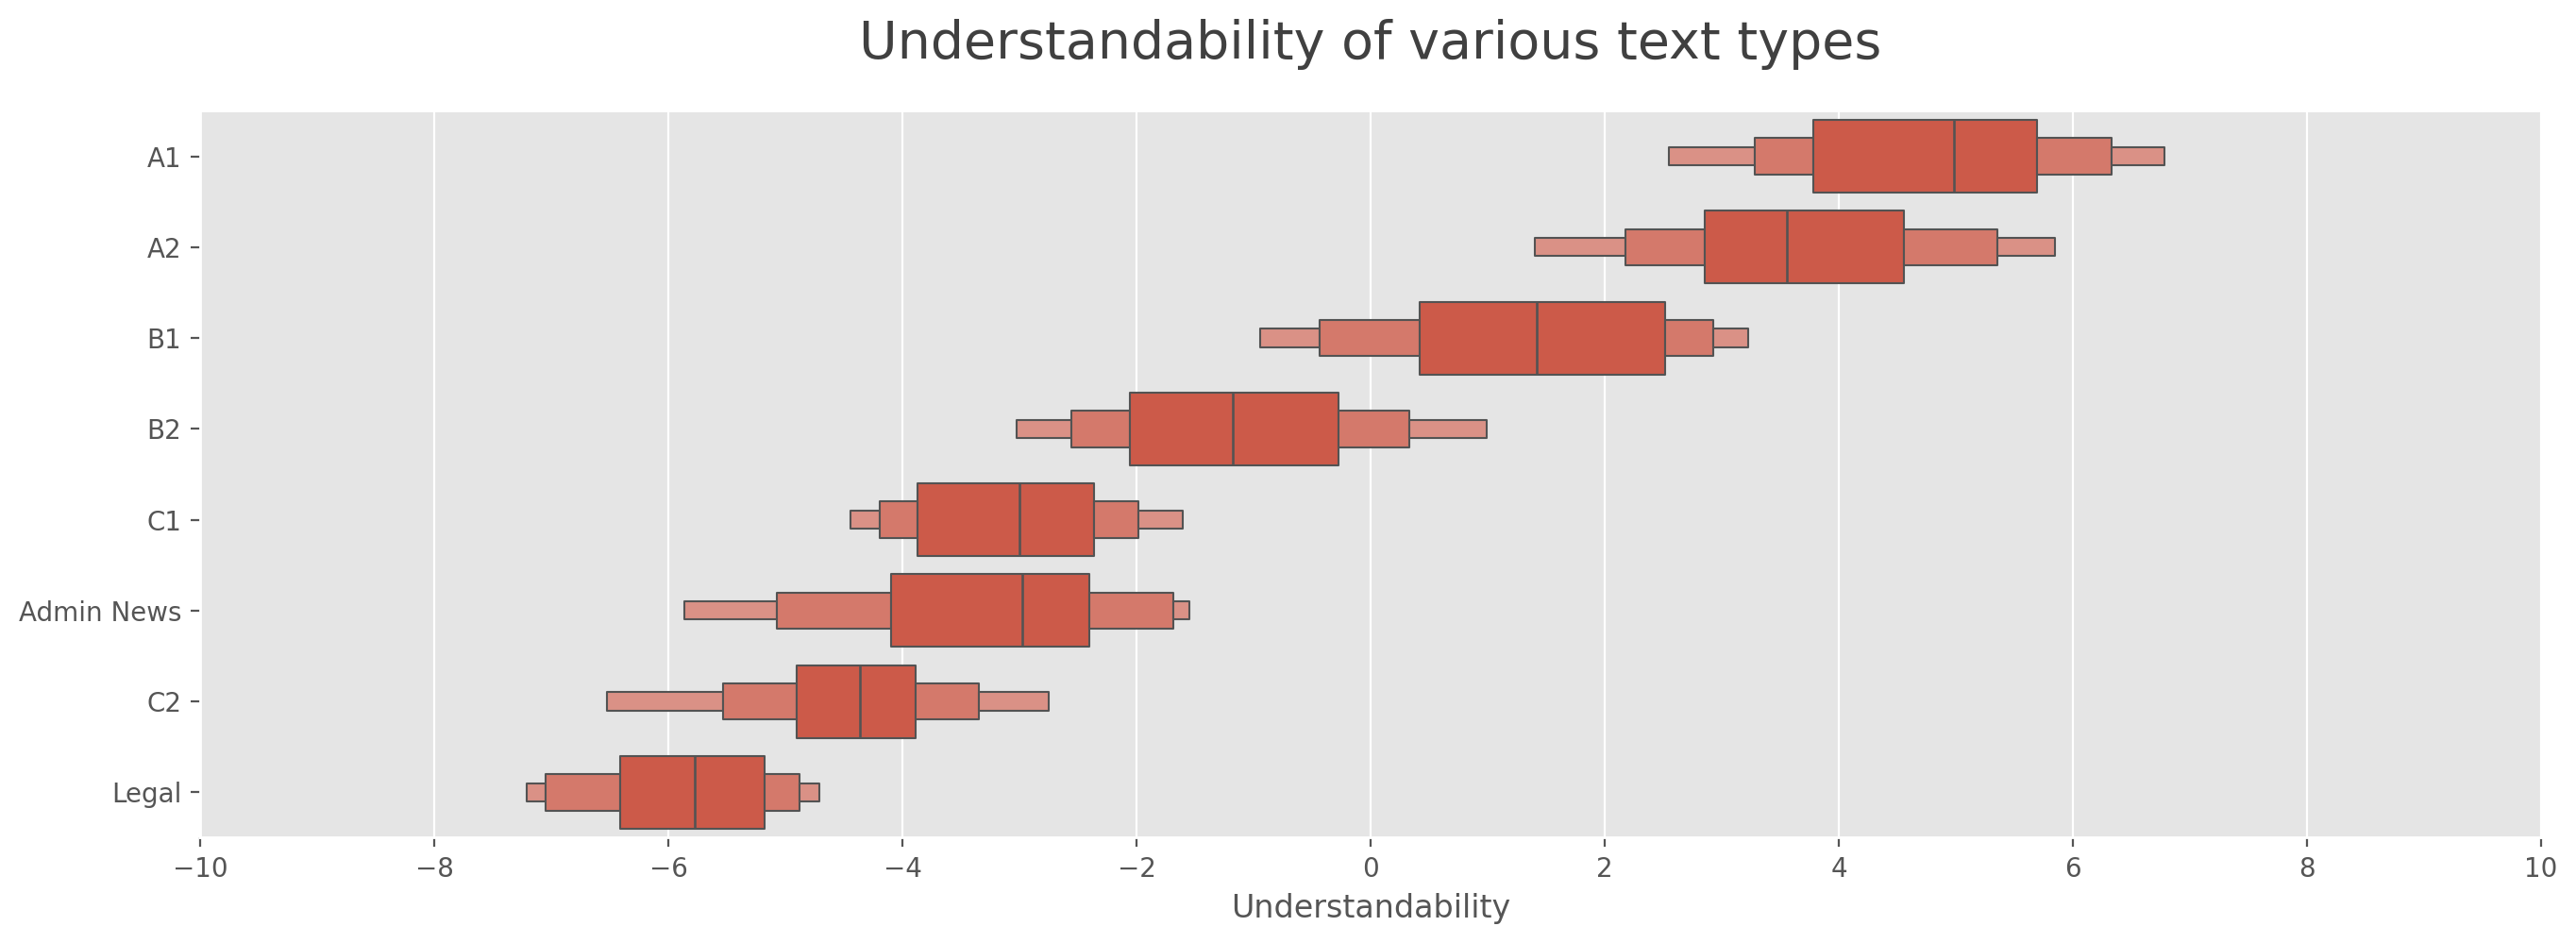

In [24]:
fig, ax = plt.subplots(figsize=(16, 5))
sns.boxenplot(
    data=df_test,
    x="zix",
    y="text_type",
    order=order,
    orient="h",
    color=DEFAULT_COLORS[0],
    ax=ax,
    showfliers=False,
)
ax.set_title("Understandability of various text types", size=20, pad=20)
ax.set_xlabel("Understandability")
ax.set_ylabel("")
ax.set_xticks(np.arange(-10, 11, 2))
plt.show()

Our feature importances show a balance between syntactic, semantic, and interaction features.


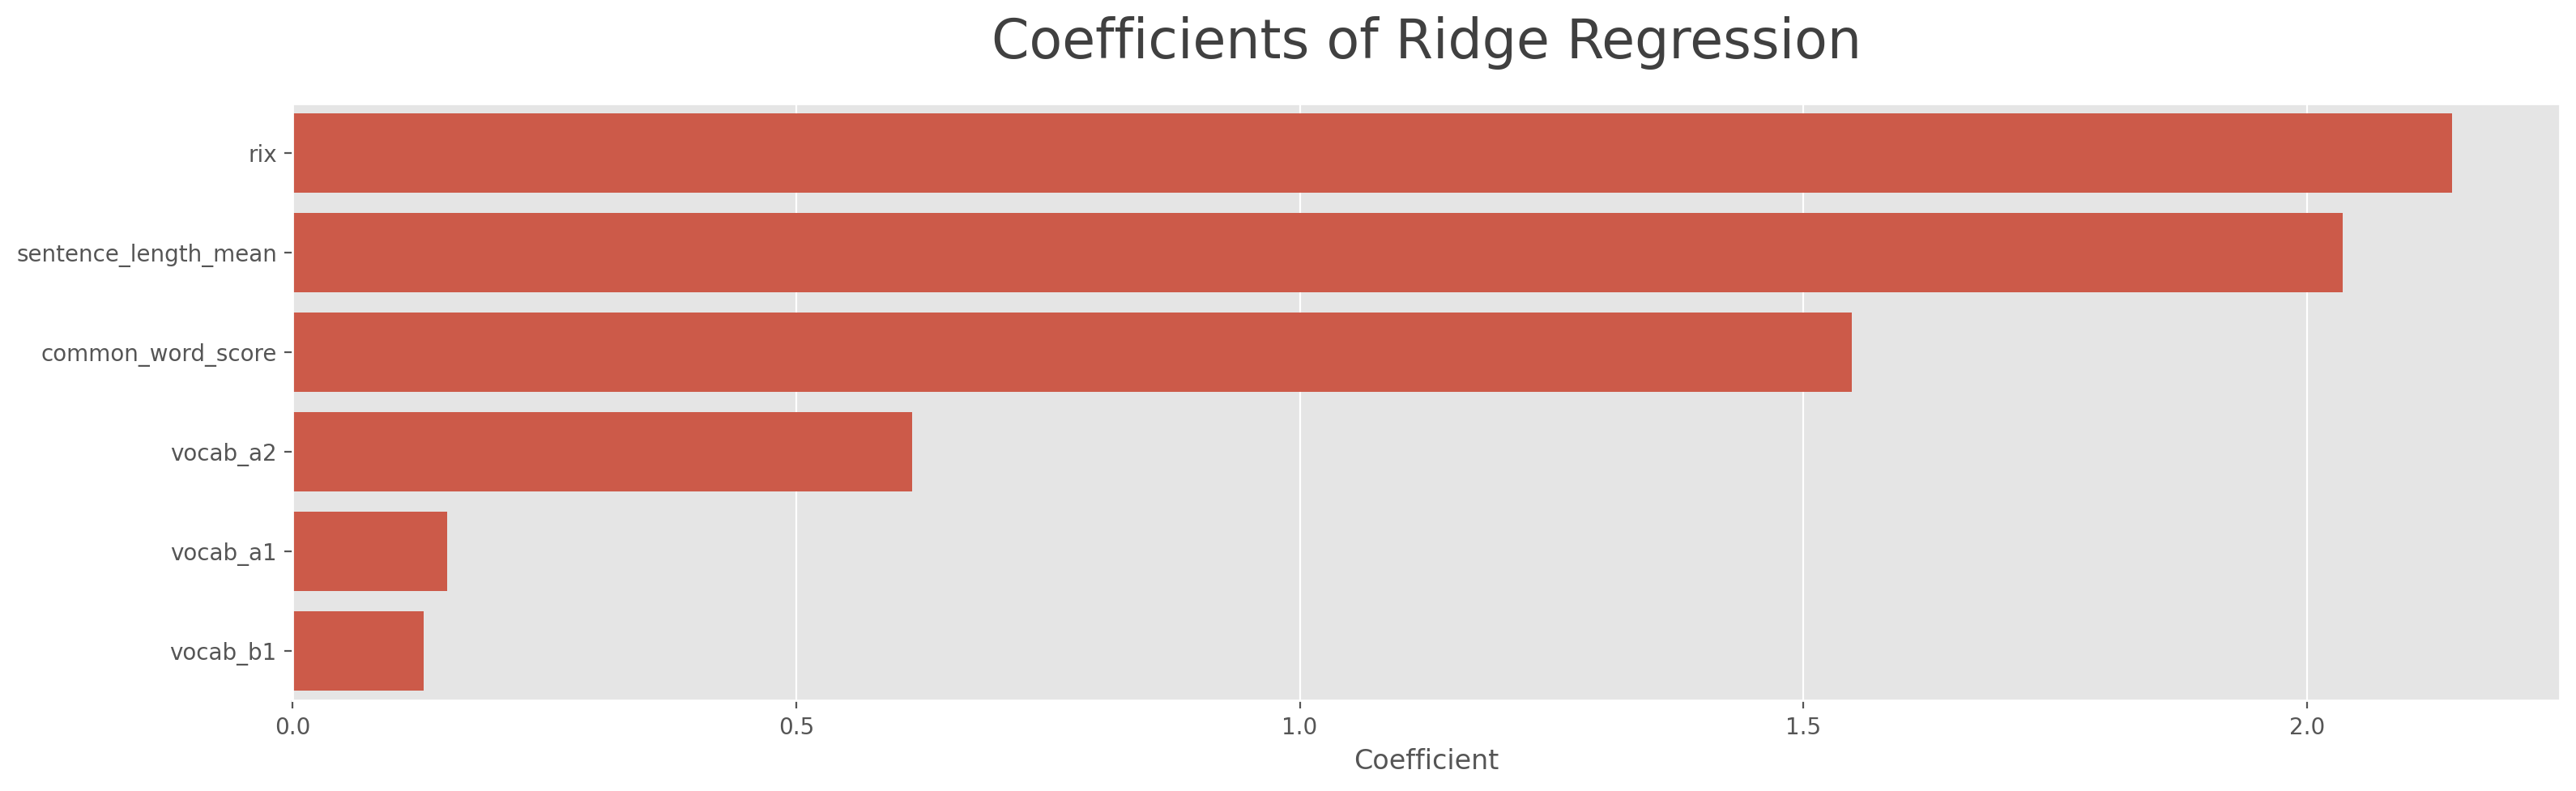

In [25]:
coefficents = sorted(
    list(zip(df_inlier[final_cols].columns, clf.coef_)),
    key=lambda x: np.abs(x[1]),
    reverse=True,
)
coef = pd.DataFrame(coefficents, columns=["feature", "coefficient"])
coef["coef_abs"] = coef.coefficient.abs()
fig, ax = plt.subplots(figsize=(16, 5))
sns.barplot(data=coef, x="coef_abs", y="feature", orient="h", ax=ax)
ax.set_title("Coefficients of Ridge Regression", size=24, pad=20)
ax.set_xlabel("Coefficient")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [26]:
coef_sum = coef.coef_abs.sum()
coef_indexed = [np.round(x / coef_sum, 2) for x in coef.coef_abs]
print("Normalized coefficients:")
display(list(zip(coef.feature, coef_indexed)))

Normalized coefficients:


[('rix', np.float64(0.32)),
 ('sentence_length_mean', np.float64(0.31)),
 ('common_word_score', np.float64(0.23)),
 ('vocab_a2', np.float64(0.09)),
 ('vocab_a1', np.float64(0.02)),
 ('vocab_b1', np.float64(0.02))]

We now try to set sensible limits for CEFR levels and create a more informative plot. CEFR levels are roughly 2 ZIX values apart.


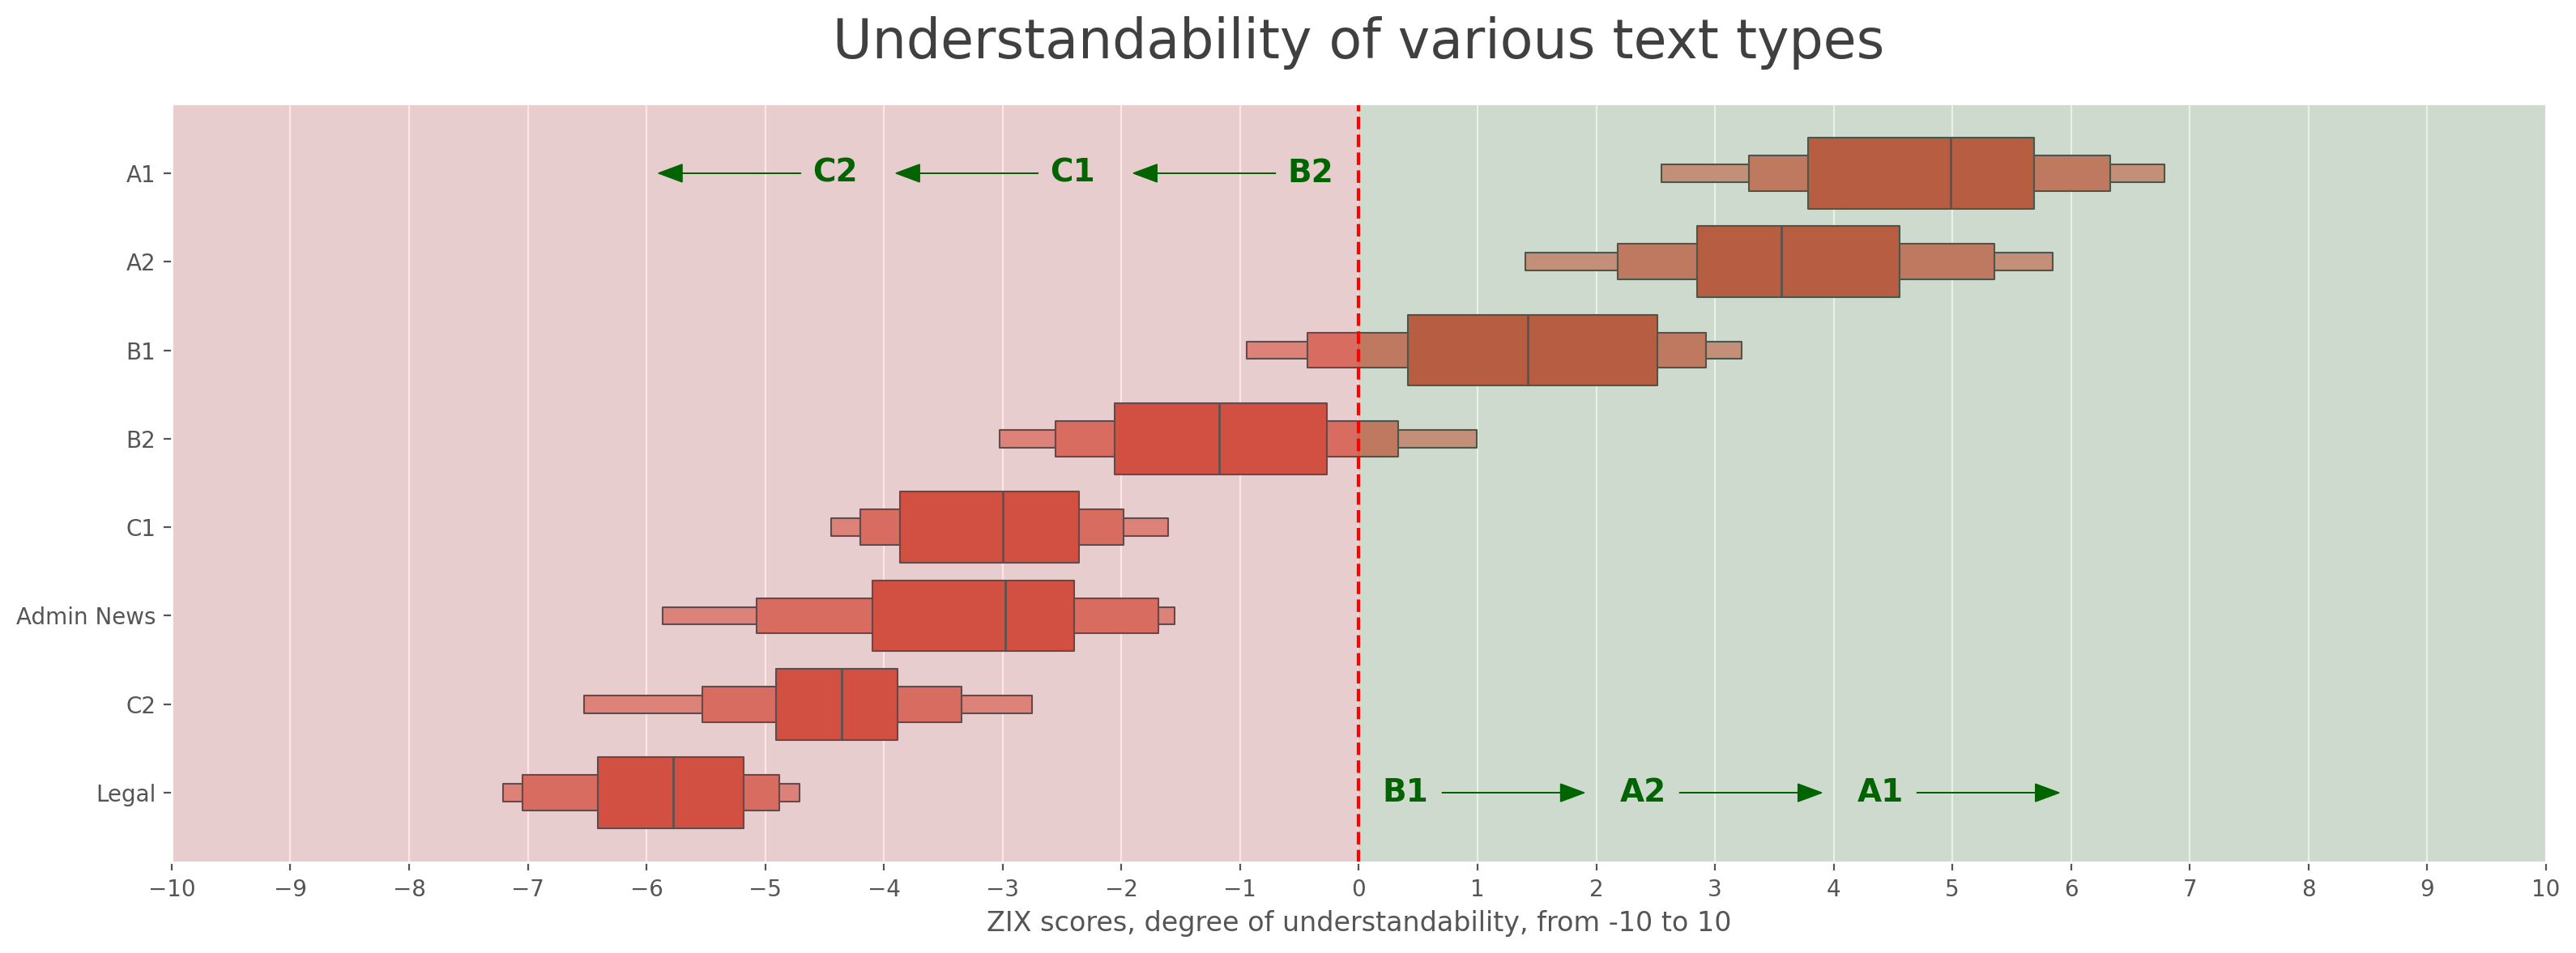

In [27]:
fig, ax = plt.subplots(figsize=(16, 6))
sns.boxenplot(
    data=df_test,
    x="zix",
    y="text_type",
    order=order,
    orient="h",
    color=DEFAULT_COLORS[0],
    ax=ax,
    showfliers=False,
)

ax.axvspan(0, 20, alpha=0.1, color="green")
ax.axvspan(-10, 0, alpha=0.1, color="red")
ax.axvline(0, color="red", linestyle="--")

params = {
    "fontsize": 14,
    "weight": "bold",
    "color": "darkgreen",
    "ha": "left",
    "va": "center",
}

# Rough estimates of CEFR levels.
# The ranges are adjusted for optical reasons.
# For the actual CEFR limits have a look at the package.
ax.text(4.2, 7, "A1", **params)
ax.text(2.2, 7, "A2", **params)
ax.text(0.2, 7, "B1", **params)
ax.text(-0.6, 0, "B2", **params)
ax.text(-2.6, 0, "C1", **params)
ax.text(-4.6, 0, "C2", **params)

for x_pos in (0.7, 2.7, 4.7):
    ax.arrow(
        x=x_pos,
        y=7,
        dx=1,
        dy=0,
        head_width=0.2,
        head_length=0.2,
        fc="darkgreen",
        ec="darkgreen",
    )

for x_pos in (-0.7, -2.7, -4.7):
    ax.arrow(
        x=x_pos,
        y=0,
        dx=-1,
        dy=0,
        head_width=0.2,
        head_length=0.2,
        fc="darkgreen",
        ec="darkgreen",
    )

ax.set_title("Understandability of various text types", size=24, pad=20)
ax.set_ylabel("")
ax.set_xlabel("ZIX scores, degree of understandability, from -10 to 10")
ax.set_xlim(-10, 10)
ax.set_xticks(range(-10, 11))
plt.tight_layout()
plt.savefig(f"_imgs/zix_scores.jpg", dpi=300)
plt.show()

We see that ZIX scores for the various text types are distributed over a wide range. For example, values for text type `C2` range from less than -10 up to more than -3. We can assume that we get a sensible indication from the scores. However, we'll likely encounter edge cases and outliers.


### Procedure

- Our objective was to **develop an understandability index for German texts** that provides a continuous score indicating how understandable a given text is, beyond just readability.
- In the absence of open datasets with ground truth, we created our own dataset.
- We generated text samples using Large Language Models (LLMs), incorporating the Common European Framework of Reference (CEFR) scale in the prompts, from A1 (beginner) to C2 (proficient).
- We extracted various linguistic features from the text data and selected a subset of six features representing both syntactic and semantic properties.
- By adding interaction terms, we expanded the feature set to a total of 14 features.
- To address outliers, we modeled the feature distribution using a Gaussian Mixture Model.
- We employed a Ridge Regressor to model the data, using the CEFR levels converted to integers (1 to 6) as a proxy for the continuous difficulty of the texts.
- The Ridge model predictions were adjusted to range from -10 to 10, with 0 approximately marking the boundary between B1 and B2 levels.

### Results

- The results are promising. Testing the index with various corpora showed that it provided helpful indications of text difficulty.

### Limitations

- **The most significant limitation is the lack of ground truth data** for both developing and validating our index. We relied on synthetic data generated by LLMs, without certainty that these texts accurately reflect CEFR levels.
- Several educated guesses were made during the project, particularly in estimating the difficulties of different text types in our training data.
- As a result, the metric should be used as an indicative and pragmatic measure rather than a definitive one.
